#  Projet Machine Learning

### Your names
Your link to the github page of the project

Link to open the notebook in Google colab

**Insérer une table des matières**

## 1) Sujet

Challenge Data from College de France ou Le Lab Banque de France : https://challengedata.ens.fr/challenges/97

### 1.1) Contexte

L'objectif du challenge est de modéliser les variations journalières du prix des contrats futures d'électricité pour la France et l'Allemagne à partir de variables explicatives météorologiques, énergétiques et commerciales.

Il s'agit d'un problème de régression supervisée dans lequel la variable cible correspond à la variation du prix de l'électricité à court terme (24h). L'objectif principal est d'expliquer les variations relatives du prix plutôt qu'en estimer la valeur. Cela est reflété par la métrique de corrélation de Spearman qui mesure la capacité du modèle à correctement ordonner les observations. Les données incluent notamment des variations journalières du prix des matières premières (Gaz, Charbon et futures sur les émissions carbone), des mesures météorologiques (température, pluie et vent), des mesures de productions (gaz naturel, charbon, hydrolique, nucléaire, photovoltaïque, éolienne, lignite) ainsi que des mesures d'utilisation électrique (consommation, exports, échanges entre la France et l'Allemagne).

Contexte du marché de l'électricité : 
Le marché de l'électricité est un marché où l'actif est physique et non stockable. Son prix est fixé par le coût marginal de la dernière unité de production (merit order). La France et l'Allemagne au dela que leur proximité et de leur frontière en commun, importent et exportent de l'électricité entre leur deux pays. En effet, ayant des mix énergétiques bien différents (plutôt nucléaire pour la France et renouvelable pour l'Allemagne), des arbitrages peuvent avoir lieu entre ces deux pays.

Lors d'évènement météorologique où le vent et le soleil sont absents, l'Allemagne doit allumer leurs centrales à charbon. Afin de palier à cette méthode de production d'électricité qui coûte cher, l'Allemagne peut acheter de l'électricité produite par les centrales française. Nous voyons donc tout l'intérêt d'étudier ces deux pays, lié dans la production d'électricité.

### 1.2) Description des données

Index des données

**Variables explicatives**

**Variable cible**


### 1.3) Description du benchmark

## 2) Problématique 

## 3) Préparation des données

### 3.1) Importations des bibliothèques

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk

from pathlib import Path
import os

from scipy.stats import spearmanr
from sklearn.metrics import *

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor


### 3.2) Importation des données

##### Importation de nos tables en dataframe pandas

In [29]:
# data set entrainement
possible_paths = [
    Path("/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"),
    Path("/Users/liessenathan/Desktop/M2/ML/PROJET-QRT-ELEC")
]
path = next((p for p in possible_paths if p.exists()), None)
path = str(path)

x_train = pd.read_csv(os.path.join(path, "X_train_NHkHMNU.csv")).sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(os.path.join(path, "y_train_ZAN5mwg.csv"))

# ensemble de test
x_test = pd.read_csv(os.path.join(path, "X_test_final.csv"))
y_test = pd.read_csv(os.path.join(path, "y_test_random_final.csv"))

##### Vérification des tailles des fichiers

In [3]:
display(x_train.dtypes)
display(x_train.shape)

ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

(1494, 35)

### 3.3) Exploration des données 

#### Informations sur notre dataset + interprétation

In [4]:
# Y a-t-il chevauchement temporel entre train et test ?
print("Train DAY_ID :", x_train['DAY_ID'].min(), "→", x_train['DAY_ID'].max())
print("Test  DAY_ID :", x_test['DAY_ID'].min(), "→", x_test['DAY_ID'].max())
print("Jours communs :", set(x_train['DAY_ID']) & set(x_test['DAY_ID']))

# Répartition des pays
print("\nTrain countries :", x_train['COUNTRY'].value_counts().to_dict())
print("Test  countries :", x_test['COUNTRY'].value_counts().to_dict())

# Combien d'observations par (DAY_ID, COUNTRY) ?
print("\nDoublons (DAY_ID, COUNTRY) train :", 
      x_train.duplicated(subset=['DAY_ID', 'COUNTRY']).sum())

Train DAY_ID : 0 → 1215
Test  DAY_ID : 4 → 1214
Jours communs : set()

Train countries : {'FR': 851, 'DE': 643}
Test  countries : {'FR': 365, 'DE': 289}

Doublons (DAY_ID, COUNTRY) train : 0


Donc les jours sont disjoints mais entrelacés : ce n'est pas un split temporel pur (passé→futur), c'est un split aléatoire au niveau du jour. Les jours ont été tirés au hasard et répartis entre train et test, sur la même période globale.

In [5]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


#### Informations sur nos features + interprétation

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

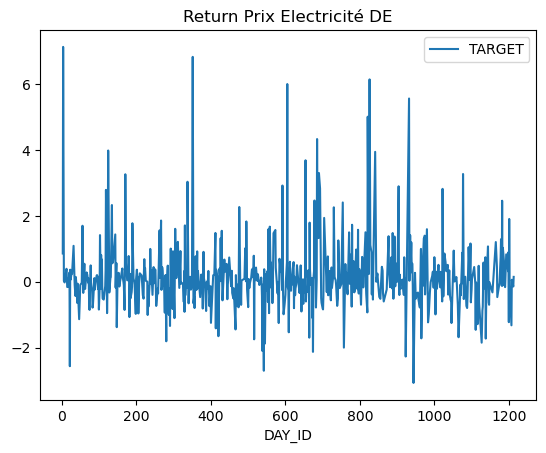

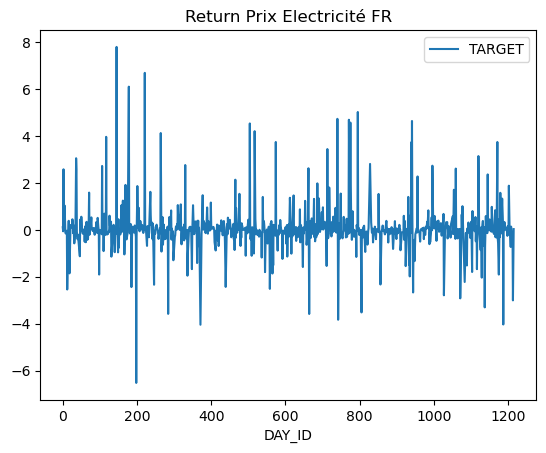

In [6]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

#### Corrélation entre les features et la cible (V de Cramer ou test Chi-deux ou kruskall-wallis selon si les features et la cible sont continues ou catégorielles)

## 4) Traitement et création de nouvelles features

### 4.2) Traitement des valeurs manquantes (Imputation)

### 4.2.b) Flux Analysis

Logiquement on a 
- DE_FR_EXCHANGE = - FR_DE_EXCHANGE
- DE_NET_EXPORT = - DE_NET_IMPORT
- FR_NET_EXPORT = - FR_NET_IMPORT

In [30]:
flow_pairs = [
    ("DE_FR_EXCHANGE", "FR_DE_EXCHANGE"),
    ("DE_NET_EXPORT", "DE_NET_IMPORT"),
    ("FR_NET_EXPORT", "FR_NET_IMPORT"),
    ]


x_train = x_train.sort_values("DAY_ID")

flux_cols = [c for pair in flow_pairs for c in pair]

display(x_train[["DAY_ID", "COUNTRY"] + flux_cols])
display(x_train.isna().sum().sort_values(ascending=False))

,DAY_ID,COUNTRY,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,DE_NET_IMPORT,FR_NET_EXPORT,FR_NET_IMPORT
742,0,FR,-0.079296,0.079296,NaN,NaN,0.650577,-0.650577
1211,1,FR,0.331356,-0.331356,0.405549,-0.405549,0.778627,-0.778627
1468,2,DE,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
1408,2,FR,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
329,3,FR,-1.051716,1.051716,-1.881881,1.881881,-0.612133,0.612133
...,...,...,...,...,...,...,...,...
986,1212,DE,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1007,1212,FR,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
873,1213,FR,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222
1465,1213,DE,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222


DE_NET_IMPORT       124
DE_NET_EXPORT       124
FR_RAIN              94
FR_TEMP              94
DE_WIND              94
FR_WIND              94
DE_TEMP              94
DE_RAIN              94
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
COUNTRY               0
ID                    0
DAY_ID                0
DE_GAS                0
FR_GAS                0
DE_CONSUMPTION        0
FR_CONSUMPTION        0
FR_NUCLEAR            0
DE_NUCLEAR            0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
DE_WINDPOW            0
DE_SOLAR              0
FR_RESIDUAL_LOAD      0
DE_RESIDUAL_LOAD      0
DE_LIGNITE            0
FR_WINDPOW            0
FR_SOLAR              0
GAS_RET               0
COAL_RET              0
CARBON_RET            0
dtype: int64

### 4.2.b) Completion

### Median == Approche finale

In [8]:
# def median_completion(df, columns_to_fill) -> pd.DataFrame:
#     """
#     Arg : df à compléter
#     """
#     x_median = df.copy()

#     for col in columns_to_fill:
#         x_median[col] = x_median[col].fillna(
#             x_median.groupby("COUNTRY")[col].transform("median")
#         )
    
#     return x_median

# colums_to_fill_train = x_train.isna().sum()[x_train.isna().sum() > 0].index
# colums_to_fill_test = x_test.isna().sum()[x_test.isna().sum() > 0].index

# # apply completion to both test and train
# x_train_median, x_test_median = median_completion(x_train, colums_to_fill_train), median_completion(x_test, colums_to_fill_test)

In [31]:
def apply_median_completion(df, medians, columns):
    df_filled = df.copy()

    for col in columns:
        df_filled[col] = df_filled[col].fillna(
            df_filled["COUNTRY"].map(medians[col])
        )
    return df_filled

# columns with NaN in train
columns_to_fill = x_train.columns[x_train.isna().any()]

# compute medians ONLY from train
train_medians = x_train.groupby("COUNTRY")[columns_to_fill].median()

# fill both datasets using train medians
x_train_median = apply_median_completion(x_train, train_medians, columns_to_fill)
x_test_median = apply_median_completion(x_test, train_medians, columns_to_fill)

### Outliers

In [10]:
import pandas as pd
import numpy as np


def detect_outliers_quantile(df, columns=None, lower_q=0.05, upper_q=0.95):
    """
    Detect outliers using quantiles (e.g., 5% and 95%)

    Parameters
    ----------
    df : pd.DataFrame
    columns : list or None
        Columns to analyze (default = numeric columns)
    lower_q : float
        Lower quantile (default = 0.05)
    upper_q : float
        Upper quantile (default = 0.95)

    Returns
    -------
    summary : pd.DataFrame
    outlier_rows : dict
    """
    if columns is None:
        columns = df.select_dtypes(include=np.number).columns

    summary = []
    outlier_rows = {}

    for col in columns:
        q_low = df[col].quantile(lower_q)
        q_high = df[col].quantile(upper_q)

        mask = (df[col] < q_low) | (df[col] > q_high)
        n_outliers = mask.sum()

        summary.append({
            "column": col,
            "q5": q_low,
            "q95": q_high,
            "n_outliers": n_outliers,
            "pct_outliers": round(100 * n_outliers / len(df), 2)
        })

        outlier_rows[col] = df.loc[mask]

    summary_df = pd.DataFrame(summary).sort_values("n_outliers", ascending=False)

    return summary_df, outlier_rows

summary, outliers = detect_outliers_quantile(x_train)
summary


,column,q5,q95,n_outliers,pct_outliers
0,ID,107.650000,2047.350000,150,10.04
24,FR_RESIDUAL_LOAD,-1.171442,1.753941,150,10.04
10,DE_GAS,-0.561842,2.130525,150,10.04
11,FR_GAS,-1.127826,1.999186,150,10.04
14,DE_HYDRO,-0.931033,2.479691,149,9.97
32,COAL_RET,-1.555821,1.713644,149,9.97
31,GAS_RET,-1.590973,1.909324,149,9.97
23,DE_RESIDUAL_LOAD,-1.471995,1.430747,149,9.97
22,DE_LIGNITE,-2.016037,0.913233,149,9.97
21,FR_WINDPOW,-0.889793,2.821165,149,9.97


### 4.1) Ajout de nouvelles features et création TRAIN et TEST

Le prix de l'électricité spot (et donc sa variation journalière, qui est ta cible) est déterminé par le coût marginal de production : à chaque instant, on empile les centrales par ordre de coût croissant, et le prix est fixé par la dernière centrale appelée pour satisfaire la demande. Cette logique s'appelle le merit order.

Conséquences directes :

* Plus la demande résiduelle (consommation moins renouvelables, qui sont quasi-gratuites) est élevée, * plus on appelle des centrales chères → prix élevé.
* Plus le coût des combustibles fossiles (gaz, charbon) et du carbone est élevé, plus les centrales marginales coûtent cher → prix élevé.
* Les échanges transfrontaliers redistribuent ces effets entre marchés couplés.

In [11]:
x_train_median.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET'],
      dtype='object')

In [32]:
def metric_train(y_true, y_pred):
    return spearmanr(y_pred, y_true).correlation

# cible alignée sur ID
x_train_median.sort_values(["COUNTRY", "DAY_ID"], inplace=True)
y_train_clean = y_train.set_index("ID").loc[x_train_median["ID"], "TARGET"]


In [33]:
def add_cross_border_flows(df):
    """Échanges transfrontaliers nets entre DE et FR."""
    # Flux net DE→FR (positif = DE exporte vers FR)
    df['NET_FLOW_DE_TO_FR'] = df['DE_FR_EXCHANGE'] - df['FR_DE_EXCHANGE']
    df['DE_NET_BALANCE']    = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_NET_BALANCE']    = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    df['DE_TRADE_BALANCE']  = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_TRADE_BALANCE']  = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    return df


def add_marginal_cost_features(df):
    """Coût marginal de production (Merit Order)."""
    # Coût effectif des centrales gaz (coût gaz + taxe carbone)
    df['GAS_CARBON_COST']  = df['GAS_RET']  + df['CARBON_RET']
    # Coût effectif des centrales charbon
    df["COAL_CARBON_COST"] = df['COAL_RET'] + df['CARBON_RET']
    # Index composite du coût fossile (proxy du prix marginal)
    df["FOSSIL_COST_INDEX"] = 0.5 * df["GAS_CARBON_COST"] + 0.5 * df["COAL_CARBON_COST"]
    # Interaction gaz × carbone : signal fort (corr=+0.10 avec TARGET)
    df["GAS_x_CARBON"] = df["GAS_RET"] * df["CARBON_RET"]
    return df


def add_residual_demand_features(df):
    """Demande résiduelle + interactions météo × production par pays."""
    for country in ["DE", "FR"]:
        renewable   = df[f"{country}_SOLAR"] + df[f"{country}_WINDPOW"] + df[f"{country}_HYDRO"]
        consumption = df[f"{country}_CONSUMPTION"]

        # Production totale ENR
        df[f"{country}_RENEWABLE_PROD"]        = renewable
        # Taux de pénétration ENR
        df[f"{country}_RENEWABLE_PENETRATION"] = renewable / consumption
        # Ratio demande résiduelle / consommation totale
        df[f"{country}_RESIDUAL_LOAD_RATIO"]   = df[f"{country}_RESIDUAL_LOAD"] / consumption
        # Prod ENR variable (vent + soleil)
        df[f"{country}_WIND_SOLAR_PROD"]        = df[f"{country}_WINDPOW"] + df[f"{country}_SOLAR"]
        # Température × demande résiduelle (effet froid sur la demande)
        df[f"{country}_TEMP_x_RESIDUAL"]        = df[f"{country}_TEMP"]  * df[f"{country}_RESIDUAL_LOAD"]
        # Vent × production éolienne
        df[f"{country}_WIND_x_WINDPOW"]         = df[f"{country}_WIND"]  * df[f"{country}_WINDPOW"]
        # Pluie × hydraulique
        df[f"{country}_RAIN_x_HYDRO"]           = df[f"{country}_RAIN"]  * df[f"{country}_HYDRO"]
        # Coût gaz pondéré par la production gaz du pays
        df[f"{country}_GAS_COST_x_PROD"]        = df["GAS_RET"]  * df[f"{country}_GAS"]
        # Coût charbon pondéré par la production charbon du pays
        df[f"{country}_COAL_COST_x_PROD"]       = df["COAL_RET"] * df[f"{country}_COAL"]

    return df


def add_thermal_need_features(df):
    """Besoin thermique par pays (ce qui doit être couvert par les fossiles)."""
    # DE : on soustrait nucléaire ET lignite
    df["DE_THERMAL_NEED"] = df["DE_RESIDUAL_LOAD"] - df["DE_NUCLEAR"] - df["DE_LIGNITE"]
    # FR : pas de colonne LIGNITE pour la France
    df["FR_THERMAL_NEED"] = df["FR_RESIDUAL_LOAD"] - df["FR_NUCLEAR"]
    return df


def add_cross_country_features(df):
    """Features cross-pays (signal d'arbitrage DE ↔ FR)."""
    df["RESIDUAL_LOAD_DIFF"]         = df["DE_RESIDUAL_LOAD"]         - df["FR_RESIDUAL_LOAD"]
    df["RENEWABLE_DIFF"]             = df["DE_RENEWABLE_PROD"]        - df["FR_RENEWABLE_PROD"]
    df["TEMP_DIFF"]                  = df["DE_TEMP"]                  - df["FR_TEMP"]
    df["NUCLEAR_DIFF"]               = df["DE_NUCLEAR"]               - df["FR_NUCLEAR"]
    df["RENEWABLE_PENETRATION_DIFF"] = df["DE_RENEWABLE_PENETRATION"] - df["FR_RENEWABLE_PENETRATION"]
    # Écart de consommation brute DE vs FR (corr=-0.06 avec TARGET)
    df["CONSUMPTION_DIFF"]           = df["DE_CONSUMPTION"]           - df["FR_CONSUMPTION"]
    return df


def add_country_encoding(df):
    """One-hot encoding de la variable COUNTRY."""
    df['COUNTRY_DE'] = (df['COUNTRY'] == 'DE').astype(int)
    df['COUNTRY_FR'] = (df['COUNTRY'] == 'FR').astype(int)
    
    return df


def add_physical_features(df):
    """
    Pipeline complet de feature engineering physique.
    Appelle toutes les sous-fonctions dans l'ordre.
    """
    df = df.copy()
    df = add_cross_border_flows(df)
    df = add_marginal_cost_features(df)
    df = add_residual_demand_features(df)
    df = add_thermal_need_features(df)
    df = add_cross_country_features(df)
    df = add_country_encoding(df)
    return df


# ── Application ───────────────────────────────────────────────────────────────
x_train_median = add_physical_features(x_train_median)
x_test_median  = add_physical_features(x_test_median)

In [34]:
x_train_median.drop(columns="COUNTRY", inplace=True)
x_test_median.drop(columns="COUNTRY", inplace=True)

In [15]:
# def add_seasonal_features(df_to_enrich, df_train_ref):
#     """
#     Ajoute les features de cycle hebdomadaire via :
#     - sin/cos pour la périodicité (continu)
#     - modulo 7 + one-hot pour les effets par jour (discret)
    
#     Note : on ne sait pas quel reste correspond à quel vrai jour
#     de la semaine, mais la structure de 7 jours est préservée.
#     """
#     df = df_to_enrich.copy()
    
#     # -------------------------------------------------------------------------
#     # Étape 1 : Reconstruction de l'ordre temporel global (train + test)
#     # -------------------------------------------------------------------------
#     all_days = sorted(
#         set(df_train_ref['DAY_ID'].unique()) | set(df['DAY_ID'].unique())
#     )
#     day_order_map = {day: i for i, day in enumerate(all_days)}
#     df['DAY_ORDER'] = df['DAY_ID'].map(day_order_map)
    
#     # -------------------------------------------------------------------------
#     # Étape 2 : Cycle hebdomadaire via sin/cos (continu, cyclique)
#     # -------------------------------------------------------------------------
#     df['SIN_WEEK'] = np.sin(2 * np.pi * df['DAY_ORDER'] / 7)
#     df['COS_WEEK'] = np.cos(2 * np.pi * df['DAY_ORDER'] / 7)
    
#     # -------------------------------------------------------------------------
#     # Étape 3 : Modulo 7 + one-hot encoding (discret)
#     # Chaque colonne DAY_MOD_x représente un "type de jour"
#     # sans qu'on sache lequel correspond à lundi, mardi, etc.
#     # -------------------------------------------------------------------------
#     df['DAY_MOD7'] = df['DAY_ORDER'] % 7
    
#     for i in range(7):
#         df[f'DAY_MOD_{i}'] = (df['DAY_MOD7'] == i).astype(int)
    
#     # DAY_MOD7 brut supprimé car redondant avec le one-hot
#     df.drop(columns='DAY_MOD7', inplace=True)
    
#     return df


# # ── Application ──────────────────────────────────────────────────────────────
# x_train_median = add_seasonal_features(x_train_median, x_train_median)
# x_test_median  = add_seasonal_features(x_test_median,  x_train_median)

# # Vérification
# new_cols = ['DAY_ORDER', 'SIN_WEEK', 'COS_WEEK'] + [f'DAY_MOD_{i}' for i in range(7)]
# print("Features hebdomadaires ajoutées :")
# print(x_train_median[new_cols].describe().round(3))
# print(f"\nNaN train : {x_train_median[new_cols].isna().sum().sum()}")
# print(f"NaN test  : {x_test_median[new_cols].isna().sum().sum()}")

Le sin/cos prévoit une variation continue entre les jours tandis que le % 7 capture chaque type de jour indépendamment.

### 4.1) Normalisation des données

In [35]:
from sklearn.preprocessing import StandardScaler

index_cols = ["ID", "DAY_ID"]
do_not_normalize= index_cols + ["COUNTRY_FR", "COUNTRY_DE"]
cols_to_normalize = [c for c in x_train_median.columns if c not in do_not_normalize]

scaler = StandardScaler()

x_train_median[cols_to_normalize] = scaler.fit_transform(x_train_median[cols_to_normalize])
x_test_median[cols_to_normalize]  = scaler.transform(x_test_median[cols_to_normalize])

### 4.) Sélection de variable

In [36]:
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr
import numpy as np

spearman_scorer = make_scorer(
    lambda y_true, y_pred: spearmanr(y_true, y_pred).correlation,
    greater_is_better=True
)

# GroupKFold sur DAY_ID : DE et FR d'un même jour restent ensemble
groups = x_train_median['DAY_ID'].values
gkf = GroupKFold(n_splits=5)

feature_cols = [c for c in x_train_median.columns if c not in index_cols]
X_cv = x_train_median.set_index("ID")[feature_cols]
y_cv = y_train_clean

# Score avec TOUTES les features (baseline)
from sklearn.ensemble import GradientBoostingRegressor

baseline = cross_val_score(
    GradientBoostingRegressor(random_state=42),
    X_cv, y_cv,
    cv=list(gkf.split(X_cv, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"Toutes features --> Spearman CV : {np.mean(baseline):.4f} ± {np.std(baseline):.4f}")

# Sélection par permutation importance (alignée sur Spearman)
from sklearn.inspection import permutation_importance
from sklearn.ensemble import GradientBoostingRegressor

# Fit sur tout le train pour calculer les importances
selector_model = GradientBoostingRegressor(random_state=42)
selector_model.fit(X_cv, y_cv)

perm_imp = permutation_importance(
    selector_model, X_cv, y_cv,
    scoring=spearman_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

print(imp_df.to_string(index=False))

# Garder les features dont l'importance > 0 (contribuent positivement)
selected_features_perm = imp_df[imp_df['importance_mean'] > 0]['feature'].tolist()
print(f"\nFeatures retenues : {len(selected_features_perm)}/{len(feature_cols)}")


Toutes features --> Spearman CV : 0.1767 ± 0.0300
                   feature  importance_mean  importance_std
        FR_WIND_SOLAR_PROD     5.985417e-02        0.009842
          DE_RESIDUAL_LOAD     4.786383e-02        0.009307
                  FR_SOLAR     4.570703e-02        0.004077
                DE_LIGNITE     4.175377e-02        0.006392
  DE_RENEWABLE_PENETRATION     3.127777e-02        0.005437
        FR_GAS_COST_x_PROD     3.011510e-02        0.008408
                  DE_SOLAR     2.074172e-02        0.005244
RENEWABLE_PENETRATION_DIFF     2.052421e-02        0.001660
                  DE_HYDRO     2.051073e-02        0.002456
        DE_GAS_COST_x_PROD     1.977196e-02        0.002588
                DE_WINDPOW     1.852931e-02        0.005744
         FR_WIND_x_WINDPOW     1.837437e-02        0.004402
         DE_WIND_x_WINDPOW     1.623184e-02        0.003824
                   DE_RAIN     1.591716e-02        0.005817
    DE_RESIDUAL_LOAD_RATIO     1.473314e-02       

### 4.4) Rééquilibrage de la base si besoin

## 5) Sélection du modèle

Nous allons donc tester plusieurs modèles sur nos données d'entrainement pour trouver celui qui maximisera l'accuracy de notre prediction. Nous nous concentrerons sur des modèles de regression

In [37]:
x_train_median = x_train_median.set_index("ID")[selected_features_perm]

In [38]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

models = {
    'XGBoost': XGBRegressor(),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-4, 4, 200), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# Comparer les modèles sur ces features
X_sel = x_train_median

res = []
for name, mod in models.items():
    print(name)
    cv_scores = cross_val_score(
        mod, X_sel, y_cv,
        cv=list(gkf.split(X_sel, y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    res.append({
        'model': name,
        'spearman_mean': np.mean(cv_scores),
        'spearman_std':  np.std(cv_scores),
    })

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]

XGBoost
Linear Regression
Ridge Regression
Lasso Regression
ElasticNet
Support Vector Regression
Decision Tree Regression
Random Forest Regression
Gradient Boosting Regression
K-Neighbors Regression


,model,spearman_mean,spearman_std
3,Lasso Regression,0.215662,0.023796
2,Ridge Regression,0.213494,0.038679
4,ElasticNet,0.213284,0.021791
5,Support Vector Regression,0.197311,0.068766
1,Linear Regression,0.182943,0.038294
8,Gradient Boosting Regression,0.178403,0.044286
7,Random Forest Regression,0.177162,0.050102
0,XGBoost,0.152017,0.043716
6,Decision Tree Regression,0.143020,0.030345
9,K-Neighbors Regression,0.063689,0.032506


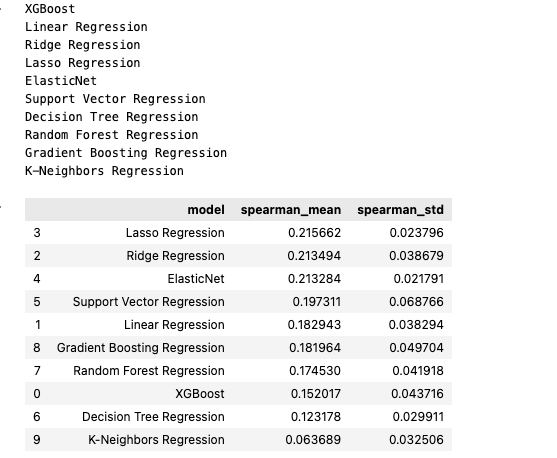

#### Conservation des colonnes avec Ridge

In [39]:
x_train_cv = x_train_median.copy()
y_train_cv = y_train_clean.copy()

In [21]:
display(x_train_cv)
display(y_train_cv)

,FR_WIND_SOLAR_PROD,DE_RESIDUAL_LOAD,FR_SOLAR,DE_LIGNITE,DE_RENEWABLE_PENETRATION,FR_GAS_COST_x_PROD,DE_SOLAR,DE_HYDRO,RENEWABLE_PENETRATION_DIFF,DE_GAS_COST_x_PROD,...,DE_CONSUMPTION,FR_NET_IMPORT,COAL_CARBON_COST,FR_RESIDUAL_LOAD,FR_NET_BALANCE,NET_FLOW_DE_TO_FR,FR_RENEWABLE_PENETRATION,NUCLEAR_DIFF,FOSSIL_COST_INDEX,DE_NET_EXPORT
ID,,,,,,,,,,,,,,,,,,,,,
111,-0.669175,0.384367,0.393153,-0.202702,-0.170612,0.739619,-0.406342,1.149539,0.004027,1.770966,...,-0.737409,-0.303058,1.099213,-0.431856,0.303058,-0.994543,-0.042222,0.602385,1.339162,-0.900193
800,1.031107,0.239485,2.204135,0.152188,-0.177757,0.055601,1.197641,1.341428,0.010978,0.507305,...,-0.835001,0.523575,-0.138647,-0.784167,-0.523575,-0.942243,-0.050936,-0.520042,0.008757,-1.774672
831,1.454203,-0.121271,2.611244,0.022521,-0.087282,-0.024202,2.155335,0.680002,0.037817,-0.180365,...,-1.077401,1.664550,0.688813,-0.445512,-1.664550,0.301672,-0.058223,0.015163,0.514644,-1.039724
779,0.972979,0.083168,1.545766,0.479002,0.239646,-0.208221,1.315815,-0.236014,0.102159,-0.198479,...,-0.549391,0.650157,0.197709,-0.728429,-0.650157,0.153632,-0.051122,0.088349,-0.063509,-0.459202
841,1.004970,-0.681208,1.804063,0.063159,-0.052125,0.402349,0.954836,-0.139675,0.038639,1.165381,...,-1.054962,2.059793,1.351110,-0.711284,-2.059793,1.512634,-0.051215,0.708387,1.825047,0.549299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2039,-0.337961,0.094178,0.419938,0.517406,0.818708,0.074455,1.765810,0.997607,0.223277,0.262612,...,-0.565777,1.537728,0.475767,-0.572052,-1.537728,0.596304,-0.045872,0.043691,0.411279,-0.352455
972,0.300770,-0.010928,-0.248034,1.580460,0.023527,-0.295958,-0.509831,-1.344236,0.044706,-0.169169,...,1.013631,-0.209738,1.546048,1.330625,0.209738,1.779127,-0.040535,-1.117922,0.947953,0.011732
1987,0.258615,-0.817137,0.909567,0.163943,-0.267769,0.038943,1.507882,-0.901073,-0.012325,-0.072603,...,-0.703433,0.692630,-0.133622,-0.486682,-0.692630,-0.129970,-0.047168,-0.555804,-0.153767,0.128139


ID
111     0.861270
800     7.138604
831     0.026374
779    -0.021227
841     0.042996
          ...   
2039    0.136028
972    -0.021766
1987   -0.425474
1688   -3.003988
1049    0.029623
Name: TARGET, Length: 1494, dtype: float64

In [40]:
feature_cols = [c for c in x_train_cv.columns if c not in ["DAY_ID"]]
x_train_cv = x_train_cv[feature_cols]
x_train_cv

,FR_WIND_SOLAR_PROD,DE_RESIDUAL_LOAD,FR_SOLAR,DE_LIGNITE,DE_RENEWABLE_PENETRATION,FR_GAS_COST_x_PROD,DE_SOLAR,RENEWABLE_PENETRATION_DIFF,DE_HYDRO,DE_GAS_COST_x_PROD,...,COAL_CARBON_COST,FR_RESIDUAL_LOAD,NET_FLOW_DE_TO_FR,FR_NET_EXPORT,FR_NET_BALANCE,DE_TRADE_BALANCE,FOSSIL_COST_INDEX,FR_RENEWABLE_PENETRATION,NUCLEAR_DIFF,DE_NET_EXPORT
ID,,,,,,,,,,,,,,,,,,,,,
111,-0.669175,0.384367,0.393153,-0.202702,-0.170612,0.739619,-0.406342,0.004027,1.149539,1.770966,...,1.099213,-0.431856,-0.994543,0.303058,0.303058,-0.900193,1.339162,-0.042222,0.602385,-0.900193
800,1.031107,0.239485,2.204135,0.152188,-0.177757,0.055601,1.197641,0.010978,1.341428,0.507305,...,-0.138647,-0.784167,-0.942243,-0.523575,-0.523575,-1.774672,0.008757,-0.050936,-0.520042,-1.774672
831,1.454203,-0.121271,2.611244,0.022521,-0.087282,-0.024202,2.155335,0.037817,0.680002,-0.180365,...,0.688813,-0.445512,0.301672,-1.664550,-1.664550,-1.039724,0.514644,-0.058223,0.015163,-1.039724
779,0.972979,0.083168,1.545766,0.479002,0.239646,-0.208221,1.315815,0.102159,-0.236014,-0.198479,...,0.197709,-0.728429,0.153632,-0.650157,-0.650157,-0.459202,-0.063509,-0.051122,0.088349,-0.459202
841,1.004970,-0.681208,1.804063,0.063159,-0.052125,0.402349,0.954836,0.038639,-0.139675,1.165381,...,1.351110,-0.711284,1.512634,-2.059793,-2.059793,0.549299,1.825047,-0.051215,0.708387,0.549299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2039,-0.337961,0.094178,0.419938,0.517406,0.818708,0.074455,1.765810,0.223277,0.997607,0.262612,...,0.475767,-0.572052,0.596304,-1.537728,-1.537728,-0.352455,0.411279,-0.045872,0.043691,-0.352455
972,0.300770,-0.010928,-0.248034,1.580460,0.023527,-0.295958,-0.509831,0.044706,-1.344236,-0.169169,...,1.546048,1.330625,1.779127,0.209738,0.209738,0.011732,0.947953,-0.040535,-1.117922,0.011732
1987,0.258615,-0.817137,0.909567,0.163943,-0.267769,0.038943,1.507882,-0.012325,-0.901073,-0.072603,...,-0.133622,-0.486682,-0.129970,-0.692630,-0.692630,0.128139,-0.153767,-0.047168,-0.555804,0.128139


In [41]:
from sklearn.linear_model import RidgeCV
from sklearn.inspection import permutation_importance

feature_cols = [c for c in x_train_cv.columns if c not in index_cols]
x_train_cv = x_train_cv[feature_cols]

selector_model = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
selector_model.fit(x_train_cv, y_train_cv)

perm_imp = permutation_importance(
    selector_model, x_train_cv, y_train_cv,
    scoring = spearman_scorer,
    n_repeats=30, #nb de melange
    random_state=42,
    n_jobs=-1
)
feature_cols_cv = x_train_cv.columns.tolist()
imp_df = pd.DataFrame({
    'feature' : feature_cols_cv,
    'importance_mean' : perm_imp.importances_mean,
    'importance_std' : perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

display(imp_df.head(50))
print(f"Nb features : {len(feature_cols_cv)} | Nb importances : {len(perm_imp.importances_mean)}")


selected_features_perm = imp_df[
    imp_df['importance_mean'] > imp_df['importance_std'] * 0.1
]['feature'].tolist()

print(f"\nFeatures retenues : {len(selected_features_perm)}/{len(feature_cols_cv)}")

ridge = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
scores = cross_val_score(
    ridge, x_train_cv[selected_features_perm], y_train_cv,
    cv=list(gkf.split(x_train_cv, y_train_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"Ridge features sélectionnées --> Spearman CV : {np.mean(scores):.4f} ± {np.std(scores):.4f}")


,feature,importance_mean,importance_std
25,GAS_x_CARBON,0.015584,0.006972
24,DE_NET_IMPORT,0.011813,0.006279
65,DE_NET_EXPORT,0.011813,0.006279
61,DE_TRADE_BALANCE,0.011813,0.006279
8,DE_HYDRO,0.010112,0.003132
0,FR_WIND_SOLAR_PROD,0.003580,0.003683
42,FR_WINDPOW,0.003575,0.003942
41,DE_WIND_SOLAR_PROD,0.003043,0.003693
45,FR_NUCLEAR,0.002914,0.001601
3,DE_LIGNITE,0.002530,0.001209


Nb features : 66 | Nb importances : 66

Features retenues : 47/66
Ridge features sélectionnées --> Spearman CV : 0.2346 ± 0.0379


0.2356 sans les lags

In [42]:
x_train_cv[selected_features_perm]

,GAS_x_CARBON,DE_NET_IMPORT,DE_NET_EXPORT,DE_TRADE_BALANCE,DE_HYDRO,FR_WIND_SOLAR_PROD,FR_WINDPOW,DE_WIND_SOLAR_PROD,FR_NUCLEAR,DE_LIGNITE,...,DE_WINDPOW,FR_WIND_x_WINDPOW,FR_RESIDUAL_LOAD,FR_RENEWABLE_PENETRATION,DE_SOLAR,DE_COAL,RENEWABLE_PENETRATION_DIFF,RESIDUAL_LOAD_DIFF,DE_RAIN_x_HYDRO,DE_RENEWABLE_PROD
ID,,,,,,,,,,,,,,,,,,,,,
111,0.640092,0.900193,-0.900193,-0.900193,1.149539,-0.669175,-1.045223,-0.893413,0.070083,-0.202702,...,-0.534089,0.095195,-0.431856,-0.042222,-0.406342,-0.133854,0.004027,0.744496,-0.428500,0.159401
800,-0.314329,1.774672,-1.774672,-1.774672,1.341428,1.031107,-0.939498,-0.007038,-1.174423,0.152188,...,-1.211495,-0.441958,-0.784167,-0.050936,1.197641,-0.591643,0.010978,0.945028,-2.237696,0.940416
831,-0.359690,1.039724,-1.039724,-1.039724,0.680002,1.454203,-0.873683,1.128493,-1.471868,0.022521,...,-0.976265,-0.282123,-0.445512,-0.058223,2.155335,0.073505,0.037817,0.308545,-1.379740,1.301465
779,-0.298254,0.459202,-0.459202,-0.459202,-0.236014,0.972979,-0.401822,0.342183,-1.542556,0.479002,...,-0.961851,-0.326918,-0.728429,-0.051122,1.315815,0.460105,0.102159,0.754245,-0.039298,0.082931
841,1.808932,-0.549299,0.549299,0.549299,-0.139675,1.004970,-0.603318,1.024237,-2.041164,0.063159,...,0.120679,-0.515000,-0.711284,-0.051215,0.954836,-0.118233,0.038639,0.059917,0.576282,0.647739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2039,-0.238639,0.352455,-0.352455,-0.352455,0.997607,-0.337961,-0.728785,1.042439,-1.510865,0.517406,...,-0.675443,-0.415335,-0.572052,-0.045872,1.765810,0.241155,0.223277,0.617940,-1.572737,1.462643
972,-0.555097,-0.011732,0.011732,0.011732,-1.344236,0.300770,0.534519,0.186651,1.538008,1.580460,...,0.709497,-0.502743,1.330625,-0.040535,-0.509831,1.523541,0.044706,-1.252662,-0.266674,-0.811540
1987,-0.307592,-0.128139,0.128139,0.128139,-0.901073,0.258615,-0.559386,1.087697,-1.024319,0.163943,...,-0.368380,-0.417582,-0.486682,-0.047168,1.507882,-0.422057,-0.012325,-0.270511,0.100114,0.157279


### Test en séparant les pays

In [25]:
# -------------------------------------------------------------------------
# Ridge séparée par pays : une pour FR, une pour DE
# -------------------------------------------------------------------------
from sklearn.linear_model import RidgeCV

def cv_spearman(model, X, y, groups, n_splits=5):
    """Retourne mean et std du Spearman CV avec GroupKFold."""
    gkf_local = GroupKFold(n_splits=n_splits)
    scores = cross_val_score(
        model, X, y,
        cv=list(gkf_local.split(X, y, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1,
    )
    return np.mean(scores), np.std(scores)

# DAY_ID n'est plus présent dans x_train_cv / x_train_median a ce stade,
# donc on reutilise le vecteur groups calcule plus haut avant la selection.
mask_fr_train = (x_train_cv['COUNTRY_FR'] == 1).values
mask_de_train = (x_train_cv['COUNTRY_DE'] == 1).values
mask_fr_test = (x_test_median['COUNTRY_FR'] == 1).values
mask_de_test = (x_test_median['COUNTRY_DE'] == 1).values

# Les dummies de pays deviennent constantes dans chaque sous-ensemble.
country_features = [
    col for col in selected_features_perm
    if col not in ['COUNTRY_FR', 'COUNTRY_DE']
]

x_train_cv_fr = x_train_cv.loc[mask_fr_train, country_features].copy()
x_train_cv_de = x_train_cv.loc[mask_de_train, country_features].copy()
y_train_cv_fr = y_train_cv.loc[mask_fr_train].copy()
y_train_cv_de = y_train_cv.loc[mask_de_train].copy()
groups_fr = groups[mask_fr_train]
groups_de = groups[mask_de_train]

x_test_fr = x_test_median.loc[mask_fr_test, country_features].copy()
x_test_de = x_test_median.loc[mask_de_test, country_features].copy()

ridge_fr = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
ridge_de = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

fr_mean, fr_std = cv_spearman(ridge_fr, x_train_cv_fr, y_train_cv_fr, groups_fr)
de_mean, de_std = cv_spearman(ridge_de, x_train_cv_de, y_train_cv_de, groups_de)

ridge_fr.fit(x_train_cv_fr, y_train_cv_fr)
ridge_de.fit(x_train_cv_de, y_train_cv_de)

results_df = pd.DataFrame([
    {
        'model': 'Ridge FR',
        'country': 'FR',
        'spearman_mean': fr_mean,
        'spearman_std': fr_std,
        'alpha': ridge_fr.alpha_,
        'n_train': len(x_train_cv_fr),
        'n_test': len(x_test_fr),
    },
    {
        'model': 'Ridge DE',
        'country': 'DE',
        'spearman_mean': de_mean,
        'spearman_std': de_std,
        'alpha': ridge_de.alpha_,
        'n_train': len(x_train_cv_de),
        'n_test': len(x_test_de),
    },
])

display(results_df.round(4))
print(f"FR Ridge  --> Spearman CV : {fr_mean:.4f} +- {fr_std:.4f} | alpha = {ridge_fr.alpha_}")
print(f"DE Ridge  --> Spearman CV : {de_mean:.4f} +- {de_std:.4f} | alpha = {ridge_de.alpha_}")
print(f"Train FR/DE : {x_train_cv_fr.shape} / {x_train_cv_de.shape}")
print(f"Test  FR/DE : {x_test_fr.shape} / {x_test_de.shape}")


,model,country,spearman_mean,spearman_std,alpha,n_train,n_test
0,Ridge FR,FR,0.1263,0.0251,1304.9020,851,365
1,Ridge DE,DE,0.3555,0.0688,622.2571,643,289


FR Ridge  --> Spearman CV : 0.1263 +- 0.0251 | alpha = 1304.9019780144015
DE Ridge  --> Spearman CV : 0.3555 +- 0.0688 | alpha = 622.2570836730231
Train FR/DE : (851, 44) / (643, 44)
Test  FR/DE : (365, 44) / (289, 44)


#### Ranking

In [26]:
from scipy.stats import rankdata

# -------------------------------------------------------------------------
# Transformation de y_train en rangs
# -------------------------------------------------------------------------
y_train_ranked = pd.Series(
    rankdata(y_train_cv),
    index=y_train_cv.index
)

print(f"y_train original : min={y_train_cv.min():.3f} | max={y_train_cv.max():.3f}")
print(f"y_train ranked   : min={y_train_ranked.min():.0f} | max={y_train_ranked.max():.0f}")

# -------------------------------------------------------------------------
# Evaluation CV — Ridge sur les rangs
# -------------------------------------------------------------------------
scores_rank = cross_val_score(
    RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    x_train_cv[selected_features_perm], y_train_ranked,
    cv=list(gkf.split(x_train_cv[selected_features_perm], y_train_ranked, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nRidge sur rangs --> Spearman CV : {np.mean(scores_rank):.4f} ± {np.std(scores_rank):.4f}")
print(f"Ridge classique --> Spearman CV : 0.2100 (référence)")

y_train original : min=-6.519 | max=7.787
y_train ranked   : min=1 | max=1494

Ridge sur rangs --> Spearman CV : 0.2439 ± 0.0180
Ridge classique --> Spearman CV : 0.2100 (référence)


In [27]:
# Meme comparaison sur le TARGET transforme en rangs
from scipy.stats import rankdata

y_all_ranked  = pd.Series(rankdata(y_all),  index=y_all.index)
y_fr_ranked   = pd.Series(rankdata(y_fr),   index=y_fr.index)
y_de_ranked   = pd.Series(rankdata(y_de),   index=y_de.index)

results_ranked = []
header = f"{'Modele':<12} | {'FR mean':>8} {'FR std':>7} | {'DE mean':>8} {'DE std':>7} | {'Global mean':>11} {'Global std':>10}"
print('=== TARGET RANK ===' )
print(header)
print('-' * 80)

for name, model in models_to_compare.items():
    fr_mean,  fr_std  = cv_spearman(model, X_fr,  y_fr_ranked,  grp_fr)
    de_mean,  de_std  = cv_spearman(model, X_de,  y_de_ranked,  grp_de)
    all_mean, all_std = cv_spearman(model, X_all, y_all_ranked, grp_all)
    results_ranked.append({'model': name,
                           'FR_mean': fr_mean,  'FR_std': fr_std,
                           'DE_mean': de_mean,  'DE_std': de_std,
                           'Global_mean': all_mean, 'Global_std': all_std})
    print(f"{name:<12} | {fr_mean:>8.4f} {fr_std:>7.4f} | {de_mean:>8.4f} {de_std:>7.4f} | {all_mean:>11.4f} {all_std:>10.4f}")

results_ranked_df = pd.DataFrame(results_ranked).sort_values('Global_mean', ascending=False)
display(results_ranked_df.round(4))


NameError: name 'y_all' is not defined

In [ ]:
results_ranked_df

In [ ]:
ridge = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
scores = cross_val_score(
    ridge, x_train_cv[selected_features_perm], y_train_ranked,
    cv=list(gkf.split(x_train_cv, y_train_ranked, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"Ridge features sélectionnées --> Spearman CV : {np.mean(scores):.4f} ± {np.std(scores):.4f}")


Ridge features sélectionnées --> Spearman CV : 0.2299 ± 0.0376


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

models = {
    'XGBoost': XGBRegressor(),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-4, 4, 200), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# Comparer les modèles sur ces features
X_sel = x_train_cv[selected_features_perm]

res = []
for name, mod in models.items():
    print(name)
    cv_scores = cross_val_score(
        mod, X_sel, y_train_cv,
        cv=list(gkf.split(X_sel, y_train_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    res.append({
        'model': name,
        'spearman_mean': np.mean(cv_scores),
        'spearman_std':  np.std(cv_scores),
    })

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]

XGBoost
Linear Regression
Ridge Regression
Lasso Regression
ElasticNet
Support Vector Regression
Decision Tree Regression
Random Forest Regression
Gradient Boosting Regression
K-Neighbors Regression


,model,spearman_mean,spearman_std
2,Ridge Regression,0.229540,0.028285
4,ElasticNet,0.213775,0.021132
3,Lasso Regression,0.213174,0.019755
1,Linear Regression,0.188457,0.027370
5,Support Vector Regression,0.188147,0.033622
8,Gradient Boosting Regression,0.171550,0.035033
7,Random Forest Regression,0.163752,0.043537
0,XGBoost,0.086144,0.033287
9,K-Neighbors Regression,0.084657,0.062158
6,Decision Tree Regression,0.078940,0.036033


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

# -------------------------------------------------------------------------
# Grille d'hyperparamètres à explorer
# -------------------------------------------------------------------------
param_dist = {
    'n_estimators':     [200, 500, 1000],       # nombre d'arbres
    'max_depth':        [2, 3, 4],              # profondeur max — faible pour éviter l'overfit
    'learning_rate':    [0.01, 0.05, 0.1],      # pas d'apprentissage
    'subsample':        [0.6, 0.8, 1.0],        # fraction des observations par arbre
    'colsample_bytree': [0.6, 0.8, 1.0],        # fraction des features par arbre
    'reg_alpha':        [0, 0.1, 1.0],          # régularisation L1
    'reg_lambda':       [1, 5, 10],             # régularisation L2
    'min_child_weight': [1, 3, 5],              # poids minimum par feuille
}

# -------------------------------------------------------------------------
# Recherche aléatoire avec GroupKFold
# -------------------------------------------------------------------------
xgb = XGBRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,                          # nombre de combinaisons testées
    cv=list(gkf.split(
        x_train_cv[selected_features_perm],
        y_train_cv,
        groups=groups
    )),
    scoring=spearman_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_train_cv[selected_features_perm], y_train_cv)

print(f"\nMeilleur Spearman CV : {search.best_score_:.4f}")
print(f"Meilleurs paramètres : {search.best_params_}")

# -------------------------------------------------------------------------
# Evaluation du meilleur modèle en CV
# -------------------------------------------------------------------------
scores_xgb = cross_val_score(
    search.best_estimator_,
    x_train_cv[selected_features_perm], y_train_cv,
    cv=list(gkf.split(x_train_cv[selected_features_perm], y_train_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)
print(f"\nXGBoost tuné --> Spearman CV : {np.mean(scores_xgb):.4f} ± {np.std(scores_xgb):.4f}")
print(f"Ridge classique --> Spearman CV : 0.2100 (référence)")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Meilleur Spearman CV : 0.2037
Meilleurs paramètres : {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

XGBoost tuné --> Spearman CV : 0.2037 ± 0.0337
Ridge classique --> Spearman CV : 0.2100 (référence)


In [ ]:
# -------------------------------------------------------------------------
# Génération du fichier de soumission — Ridge global (meilleur modèle CV : 0.23)
# -------------------------------------------------------------------------

# Entraînement final sur TOUT le train avec les 50 features sélectionnées
ridge_submit = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10, scoring=spearman_scorer)
ridge_submit.fit(x_train_cv[selected_features_perm], y_train_cv)

print(f"Alpha sélectionné : {ridge_submit.alpha_}")

# Prédiction sur x_test_median avec les mêmes features
y_pred_submit = ridge_submit.predict(x_test_median[selected_features_perm])

# Construction du fichier de soumission
submission = pd.DataFrame({
    "ID":     x_test_median["ID"].values,
    "TARGET": y_pred_submit
})

# Vérifications avant soumission
assert submission.shape == (654, 2), f"Shape incorrecte : {submission.shape}"
assert submission["TARGET"].isna().sum() == 0, "NaN détectés dans TARGET !"
assert set(submission["ID"]) == set(x_test["ID"]), "Les ID ne correspondent pas à X_test !"

print(f"Shape : {submission.shape}")
print(f"NaN   : {submission['TARGET'].isna().sum()}")
print(submission.head(10))

# Sauvegarde
submission.to_csv("submission_ridge_weekly_features.csv", index=False)
print("\nFichier 'submission_ridge.csv' sauvegardé — prêt à soumettre !")

In [ ]:
print("Colonnes train :", x_train_cv_fr.columns.tolist())
print("Colonnes test  :", x_test_fr.columns.tolist())
print("Colonnes communes :", set(x_train_cv_fr.columns) == set(x_test_fr.columns))

Nous constatons que le modèle KNeighborsRegressor prédit des valeurs avec la corrélation la plus importante donc nous allons choisir ce type modèle pour nos predictions. Mais avant de passer à la prédiction, nous allons optimiser les hyperparamètres de ce modèle.

##### **Optimisation des hyperparamètres**

In [ ]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr

# Scorer custom : corrélation de Spearman (la vraie métrique du challenge)
def spearman_scorer(y_true, y_pred):
    return spearmanr(y_true, y_pred).correlation

spearman_score = make_scorer(spearman_scorer, greater_is_better=True)

param_dist = {
    'n_neighbors': randint(3, 100),       # élargis la plage, KNN bénéficie souvent de gros k sur données bruitées
    'weights': ['uniform', 'distance'],
    'p': [1, 2],                           # 1 = Manhattan, 2 = Euclidienne
    'leaf_size': randint(10, 50),
}

random_search = RandomizedSearchCV(
    estimator=KNeighborsRegressor(n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,                             # nombre de combinaisons testées
    cv=5,
    scoring=spearman_score,
    verbose=2,
    n_jobs=-1,
    random_state=42,
)

random_search.fit(x_train_median, y_train_clean)
print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleur score Spearman CV :", random_search.best_score_)

best_model = random_search.best_estimator_

In [ ]:
y_pred_best = best_model.predict(x_test_median)
best_mse = mean_squared_error(y_test_clean, y_pred_best)
best_r2 = r2_score(y_test_clean, y_pred_best)
best_corr_spear = metric_train(y_test_clean, y_pred_best)

print(f"Best Mean Squared Error: {best_mse}")
print(f"Best R^2 Score: {best_r2}")
print(f"Best Spearman Correlation: {best_corr_spear}")

Avec notre optimisation d'hyperparamètre, nous avons identifié un modèle qui est plus précis. Nous le retiendrons donc pour la prédiction les paramètre suivant.

In [ ]:
print('Hyperparamètres optimaux :')
random_search.best_params_

## 5) Benchmark

##### **Mesure de performance demandée par le challenge**

In [ ]:
lr = LinearRegression()

x_train_clean = x_train.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Nous adaptons également cette metrique pour qu'elle soit utilisable dans nos GridSearch au moment de l'optimisation de nos hyperparamètre.

In [ ]:
custom_score = make_scorer(weighted_accuracy, greater_is_better=True)

Nous rangeons également nos methodes dans une liste pour pouvoir y aplliquer plus facilement les modèles.

In [ ]:
methods = [(X_train_1,y_train_1),(X_train_2,y_train_2),(X_train_3,y_train_3)]

##### **Création et Entrainement du modèle**

In [ ]:
comparaison=[]
result_baseline=[]
for i,method in enumerate(methods):
    X_train_method,y_train_method = method

    # Split des données
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)

    # Transformation de la cible en binaire (positif/négatif)
    y_train_method_train = (y_train_method_train['cible'] > 0).astype(int)

    # Modèle baseline : Régression Logistique
    baseline_model = LogisticRegression(max_iter=1000, random_state=42)
    baseline_model.fit(X_train_method_train, y_train_method_train)

    # Prédictions et évaluation
    y_pred_baseline = baseline_model.predict(X_train_method_test)

    # Mesure de Performance
    wacc_baseline = weighted_accuracy(y_train_method_test['cible'], y_pred_baseline)
    result_baseline.append((f"Method_{i+1}",wacc_baseline,baseline_model))
   
result_baseline = pd.DataFrame(result_baseline,columns=["Methode","W_Accuracy","Modele"])
result_baseline

Interprétations.

##### **Optimisation des hyperparamètre**

Nous garderons donc la methode 2 pour cette optimisation car c'est celle pour laquelle le modèle est le plus performant.

In [ ]:
X_train_method,y_train_method = methods[2]
X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
y_train_method_train = (y_train_method_train['cible'] > 0).astype(int)


In [ ]:
param_grid = {
    'max_iter': [100, 200, 500, 1000, 2000],  # Nombres d'itérations
    'C': [0.001, 0.01, 0.1, 1, 10, 100],      # Paramètre de régularisation
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']  # Algorithmes d'optimisation
}

# Configuration de la recherche en grille avec validation croisée
grid_search = sk.model_selection.GridSearchCV(LogisticRegression(random_state=42), param_grid=param_grid, scoring=custom_score, cv=3, n_jobs=None, verbose=0)
grid_search.fit(X_train_method_train, y_train_method_train)

# Meilleur modèle et paramètres
baseline_model = grid_search.best_estimator_
print("Meilleur modèle:", baseline_model)

In [ ]:
y_pred_optimized = baseline_model.predict(X_train_method_test)
wacc_baseline = weighted_accuracy(y_train_method_test['cible'], y_pred_optimized)
comparaison.append(["Methode_baseline","LogisticRegression",wacc_baseline])
wacc_baseline

Interprétation

##### **Prédiction des valeurs**

In [ ]:
X_test_method = X_test_3
y_test_baseline = baseline_model.predict(X_test_method)
y_test_baseline = pd.DataFrame(y_test_baseline,index=X_test_method.index,columns=['cible'])
y_test_baseline.to_csv('y_test_baseline.csv')

Nous avons testé ce résultat et nous obtenons bien le même résultats que le benchmark. 

## 6) Modèle non supervisé si possible ou à dafaut pour construire des features

Avec une méthode d'apprentissage non supervisée, on ne pourraient pas prédire directement le cible. Mais on peut envisager de l'utiliser pour explorer ou prétraiter les données avant d'utiliser un modèle supervisé.

Nous utiliserons donc d'abord une Décomposition en Composante Principales pour observer nos données, puis utiliserons un Kmeans pour regrouper nos données afin d'améliorer nos résultats de nos modèles supervisés. 

### 6.1) ACP

Nous commençons par appliquer une ACP sur nos données pour réduire le nombre de dimensions. Nous affichons la reprensentation de notre nuage de points sur 3 dimensions et la courbe de la variance expliquée en fonction du nombre de dimensions choisis pour notre décomposition.

PC1 : 20.9% | PC2 : 14.7% | PC3 : 8.2%
Composantes pour 80% : 13 | pour 95% : 22


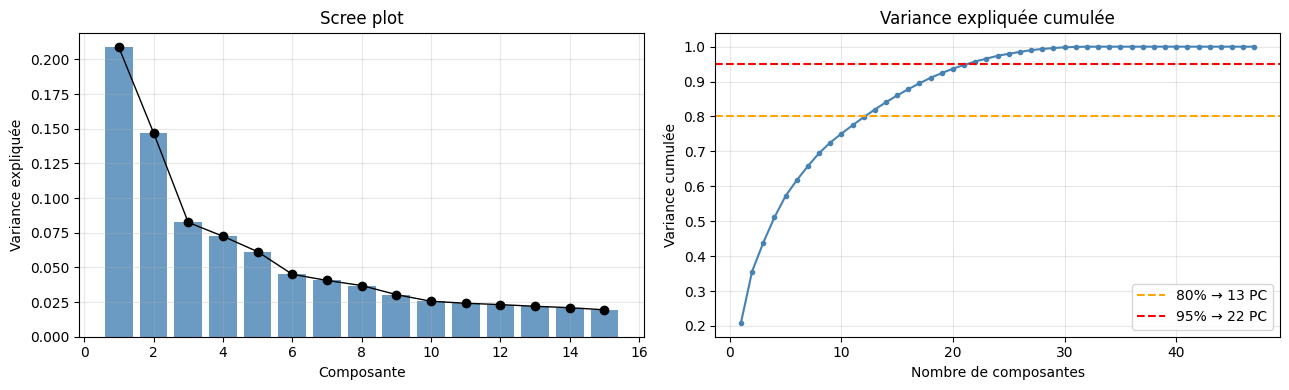

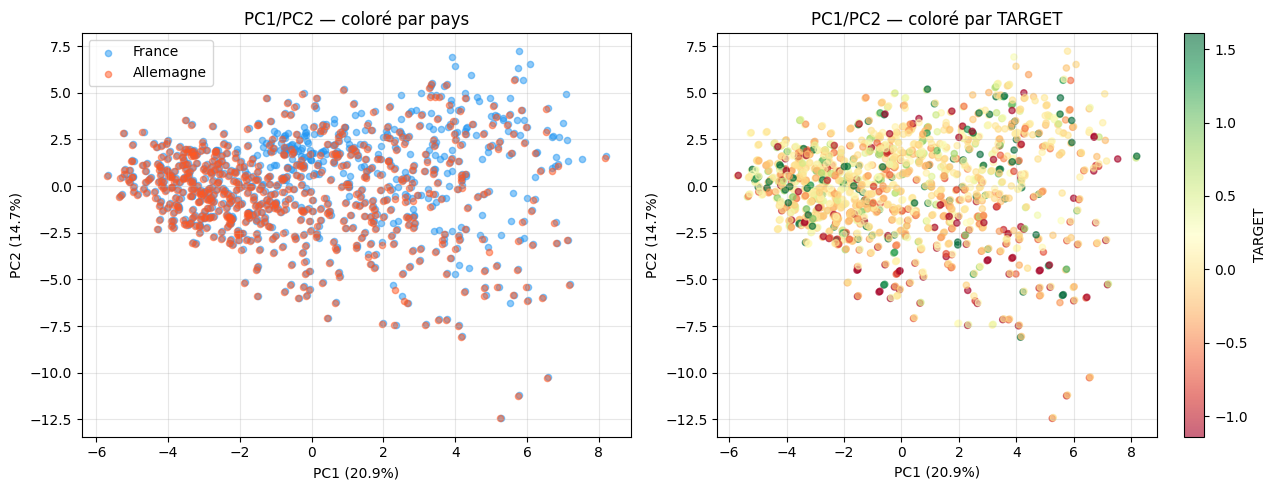

In [52]:
from sklearn.decomposition import PCA

x_train_pca = x_train_cv[selected_features_perm].copy()

country_labels = x_train[['ID','COUNTRY']].set_index('ID').loc[x_train_pca.index, 'COUNTRY']
target_vals = y_train_cv.loc[x_train_pca.index].values

# ACP complète
pca_global = PCA()
X_proj = pca_global.fit_transform(x_train_pca)

explained = pca_global.explained_variance_ratio_
cumul = np.cumsum(explained)
n95 = np.argmax(cumul >= 0.95) + 1
n80 = np.argmax(cumul >= 0.80) + 1

print(f"PC1 : {explained[0]:.1%}  PC2 : {explained[1]:.1%}  PC3 : {explained[2]:.1%}")
print(f"Composantes pour 80% : {n80} , pour 95% : {n95}")

# Scree plot + variance cumulée
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 16), explained[:15], color='steelblue', alpha=0.8)
axes[0].plot(range(1, 16), explained[:15], 'o-', color='black', lw=1)
axes[0].set(xlabel='Composante', ylabel='Variance expliquée', title='Scree plot')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(cumul)+1), cumul, 'o-', color='steelblue', ms=3)
axes[1].axhline(0.80, color='orange', ls='--', label=f'80% → {n80} PC')
axes[1].axhline(0.95, color='red',    ls='--', label=f'95% → {n95} PC')
axes[1].set(xlabel='Nombre de composantes', ylabel='Variance cumulée',
            title='Variance expliquée cumulée')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for country, color, label in [('FR', '#2196F3', 'France'), ('DE', '#FF5722', 'Allemagne')]:
    mask = country_labels.values == country
    axes[0].scatter(X_proj[mask, 0], X_proj[mask, 1],
                    c=color, alpha=0.5, s=20, label=label)
axes[0].set(xlabel=f'PC1 ({explained[0]:.1%})', ylabel=f'PC2 ({explained[1]:.1%})',
            title='PC1/PC2 — coloré par pays')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(X_proj[:, 0], X_proj[:, 1], c=target_vals,
                     cmap='RdYlGn', alpha=0.6, s=20,
                     vmin=np.percentile(target_vals, 5),
                     vmax=np.percentile(target_vals, 95))
plt.colorbar(sc, ax=axes[1], label='TARGET')
axes[1].set(xlabel=f'PC1 ({explained[0]:.1%})', ylabel=f'PC2 ({explained[1]:.1%})',
            title='PC1/PC2 — coloré par TARGET')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


**Répartition de la variance**
Les valeurs PC1, PC2, PC3 ne présentent aucune domination par l'une des composante. De plus, on remarque une décroissance progressive, sans coude net. La variance est distribuée sur de nombreuses dimensions.

**Variance cumulée - Choix du nombre de composantes**
- 13 composantes : 80% de la variance
- 22 composantes : 95% de la variance

**Graphique par pays**
FR et DE sont fortement mélangés. L'ACP globale n'est pas discriminante entre pays. Cela justifie de faire une ACP séparée par pays.

**Graphique par target**
Aucun gradient clair visible (fortement mélangé).

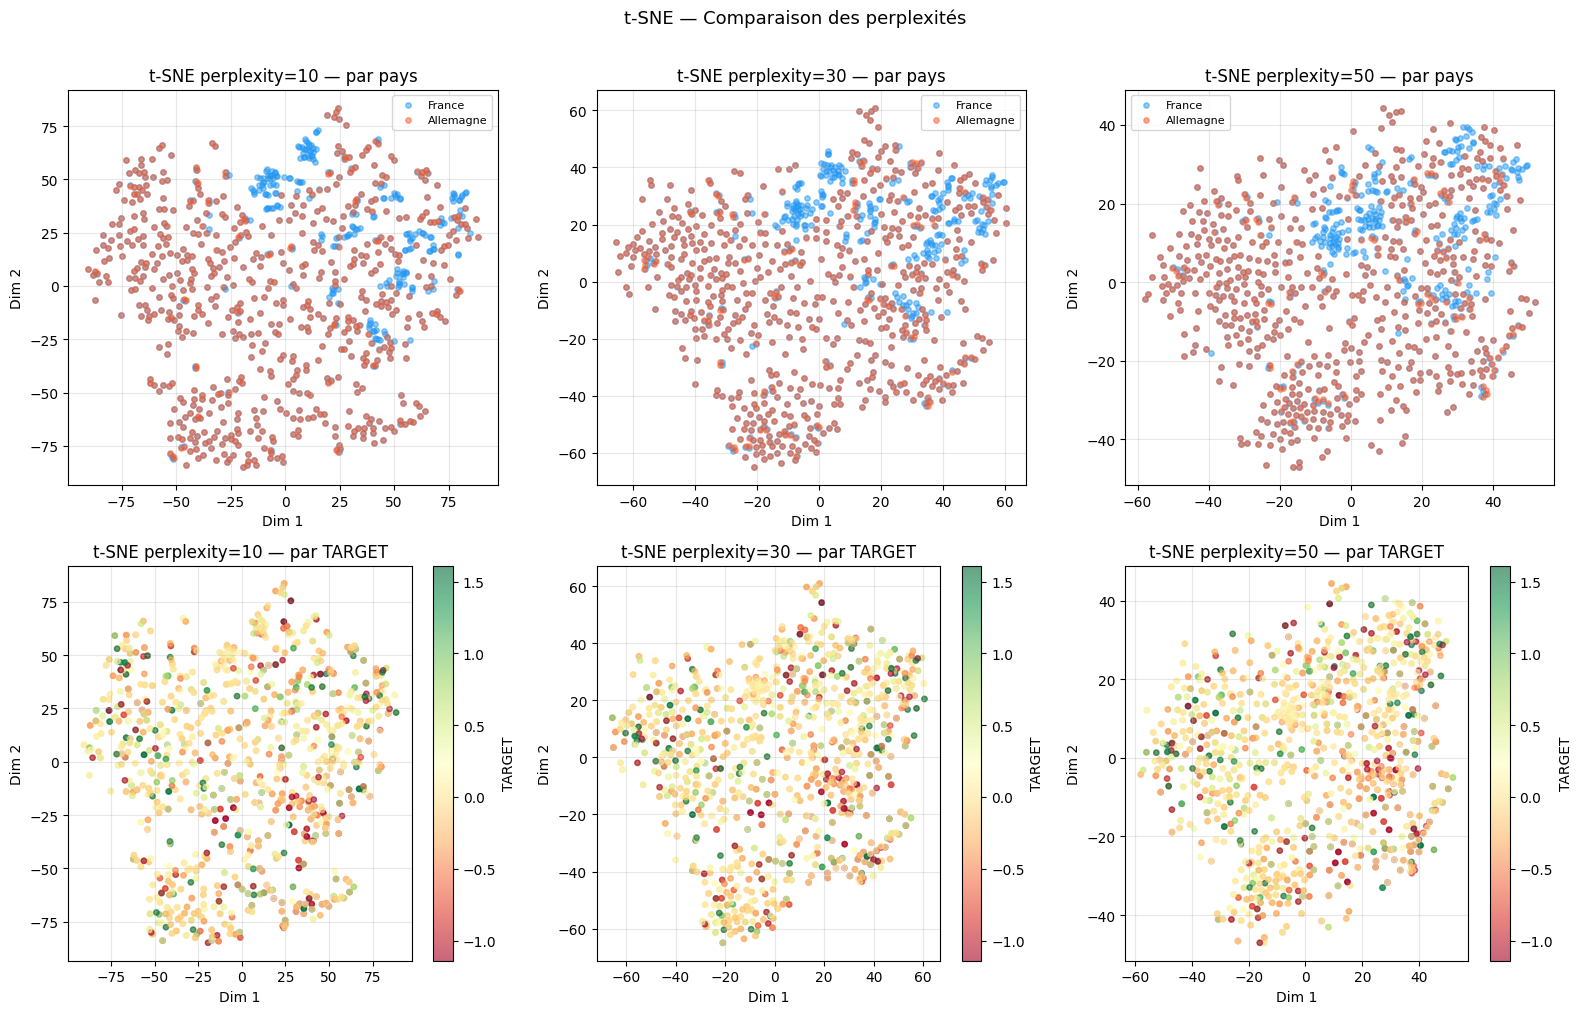

In [ ]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

X_pca_50 = PCA(n_components=min(50, x_train_pca.shape[1]),
               random_state=42).fit_transform(x_train_pca)

perplexities = [10, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp,
            max_iter=1000, learning_rate='auto',
            init='pca', random_state=42)

    X_tsne = tsne.fit_transform(X_pca_50)

    # Coloré par pays
    for country, color, label in [('FR','#2196F3','France'), ('DE','#FF5722','Allemagne')]:
        mask = country_labels.values == country
        axes[0, col].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                             c=color, alpha=0.5, s=15, label=label)
    axes[0, col].set_title(f't-SNE perplexity={perp} — par pays')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.3)
    axes[0, col].set(xlabel='Dim 1', ylabel='Dim 2')

    # Coloré par TARGET
    sc = axes[1, col].scatter(X_tsne[:, 0], X_tsne[:, 1],
                               c=target_vals, cmap='RdYlGn', alpha=0.6, s=15,
                               vmin=np.percentile(target_vals, 5),
                               vmax=np.percentile(target_vals, 95))
    plt.colorbar(sc, ax=axes[1, col], label='TARGET')
    axes[1, col].set_title(f't-SNE perplexity={perp} — par TARGET')
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].set(xlabel='Dim 1', ylabel='Dim 2')

plt.suptitle('t-SNE — Comparaison des perplexités', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


**Ligne 1 - Coloré par pays**
La France forme un cluster (nord est en bleu) tandis que l'Allemagne est très dispersée dans l'espace. Cela signifie que les jours FR ont des profils similaires entre eux tandis que les jours DE sont plus hétérogènes

**Ligne 2 - Coloré par Target**
Par de gradient spatial clair. Le Target est difficile à prédire.

FR : 851 obs x 27 features
DE : 643 obs x 34 features
France : 15 composantes pour 95% variance
Allemagne : 16 composantes pour 95% variance


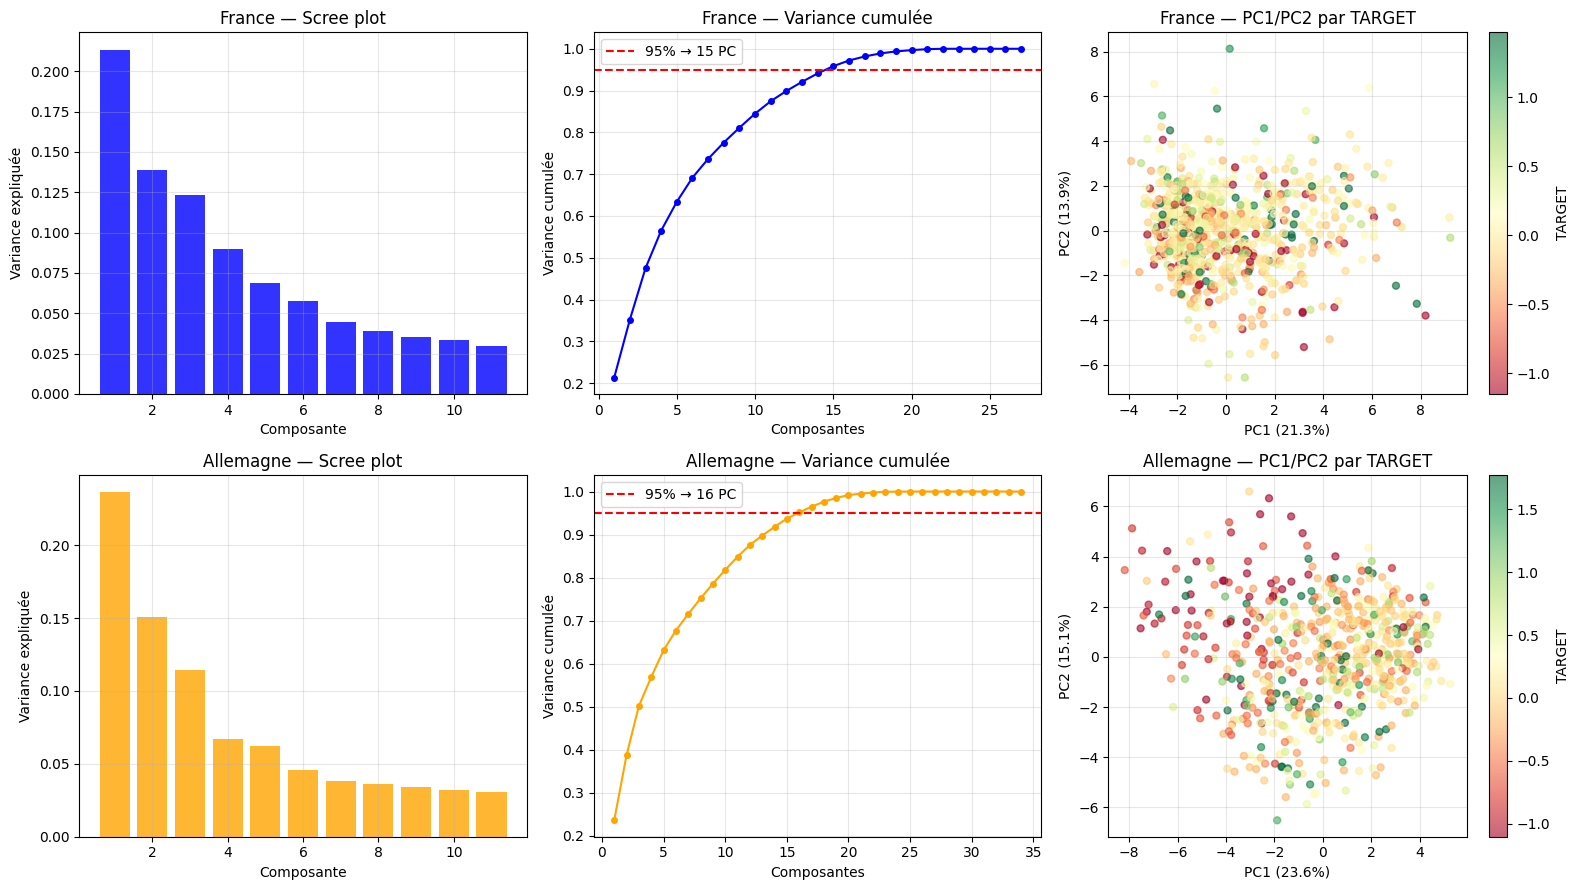

In [ ]:
# Séparation des features par pays
SHARED_FEATS = [f for f in selected_features_perm if not f.startswith('FR_') and not f.startswith('DE_')]
FR_FEATS = [f for f in selected_features_perm if f.startswith('FR_')] + SHARED_FEATS
DE_FEATS = [f for f in selected_features_perm if f.startswith('DE_')] + SHARED_FEATS

mask_fr = country_labels.values == 'FR'
mask_de = country_labels.values == 'DE'

X_fr = x_train_pca[mask_fr][FR_FEATS]
X_de = x_train_pca[mask_de][DE_FEATS]
y_fr = y_train_cv.loc[x_train_pca.index[mask_fr]].values
y_de = y_train_cv.loc[x_train_pca.index[mask_de]].values

print(f"FR : {X_fr.shape[0]} obs x {X_fr.shape[1]} features")
print(f"DE : {X_de.shape[0]} obs x {X_de.shape[1]} features")

# ACP par pays
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (X_c, y_c, label, color) in enumerate([
    (X_fr, y_fr, 'France', 'blue'),
    (X_de, y_de, 'Allemagne', 'orange'),
]):
    pca_c = PCA()
    Xp = pca_c.fit_transform(X_c)
    ev = pca_c.explained_variance_ratio_
    cumul_c = np.cumsum(ev)
    n95_c = np.argmax(cumul_c >= 0.95) + 1

    axes[row, 0].bar(range(1, min(12, len(ev)+1)), ev[:11], color=color, alpha=0.8)
    axes[row, 0].set(xlabel='Composante', ylabel='Variance expliquée',
                     title=f'{label} — Scree plot')
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(range(1, len(cumul_c)+1), cumul_c, 'o-', color=color, ms=4)
    axes[row, 1].axhline(0.95, color='red', ls='--', label=f'95% → {n95_c} PC')
    axes[row, 1].set(xlabel='Composantes', ylabel='Variance cumulée',
                     title=f'{label} — Variance cumulée')
    axes[row, 1].legend(); axes[row, 1].grid(True, alpha=0.3)

    sc = axes[row, 2].scatter(Xp[:, 0], Xp[:, 1], c=y_c,
                               cmap='RdYlGn', alpha=0.6, s=25,
                               vmin=np.percentile(y_c, 5),
                               vmax=np.percentile(y_c, 95))
    plt.colorbar(sc, ax=axes[row, 2], label='TARGET')
    axes[row, 2].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — PC1/PC2 par TARGET')
    axes[row, 2].grid(True, alpha=0.3)

    print(f"{label} : {n95_c} composantes pour 95% variance")
    if label == 'France':
        pca_fr, X_pca_fr, n95_fr = pca_c, Xp, n95_c
    else:
        pca_de, X_pca_de, n95_de = pca_c, Xp, n95_c

plt.tight_layout(); plt.show()


Les deux ACP par pays confirment que 15-16 dimensions sont nécessaires pour décrire 95% de la variance (le signal est dans de nombreuses directions). Le TARGET n'est pas capturé par les 2 premières composantes dans aucun des deux pays, ce qui justifie d'utiliser toutes les composantes (pas seulement PC1/PC2) comme input pour le clustering KMeans/GMM qui suit.



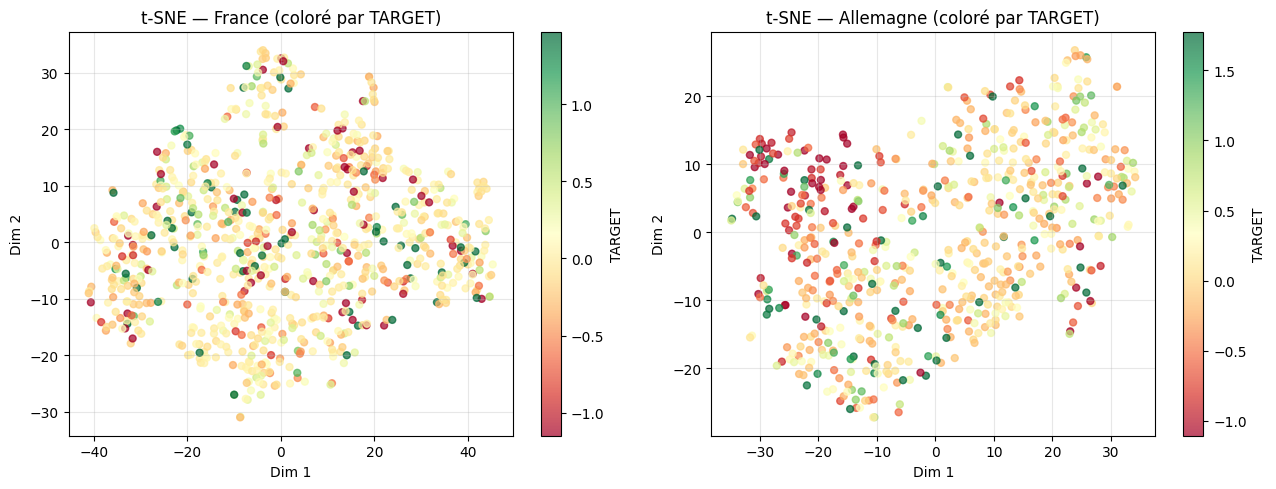

In [80]:
# ── t-SNE séparé par pays ─────────────────────────────────────────────────────
SHARED_FEATS = [f for f in selected_features_perm
                if not f.startswith('FR_') and not f.startswith('DE_')]
FR_FEATS = [f for f in selected_features_perm if f.startswith('FR_')] + SHARED_FEATS
DE_FEATS = [f for f in selected_features_perm if f.startswith('DE_')] + SHARED_FEATS

mask_fr = country_labels.values == 'FR'
mask_de = country_labels.values == 'DE'

X_fr = x_train_pca[mask_fr][FR_FEATS]
X_de = x_train_pca[mask_de][DE_FEATS]
y_fr = y_train_cv.loc[x_train_pca.index[mask_fr]].values
y_de = y_train_cv.loc[x_train_pca.index[mask_de]].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, X_c, y_c, label, color in [
    (axes[0], X_fr, y_fr, 'France', 'blue'),
    (axes[1], X_de, y_de, 'Allemagne', 'orange'),
]:
    tsne_c = TSNE(n_components=2, perplexity=30,
              max_iter=1000, learning_rate='auto',
              init='pca', random_state=42)

    Xt = tsne_c.fit_transform(X_c)

    sc = ax.scatter(Xt[:, 0], Xt[:, 1], c=y_c,
                    cmap='RdYlGn', alpha=0.7, s=25,
                    vmin=np.percentile(y_c, 5),
                    vmax=np.percentile(y_c, 95))
    plt.colorbar(sc, ax=ax, label='TARGET')
    ax.set_title(f't-SNE — {label} (coloré par TARGET)')
    ax.set(xlabel='Dim 1', ylabel='Dim 2')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Le t-SNE par pays confirme et nuance les résultats précédents :

**France** : structure quasi-aléatoire → signal prix très difficile à capturer, modèle non supervisé limité

**Allemagne** : légère ségrégation spatiale par TARGET → des régimes de marché distincts existent, le clustering a plus de sens pour DE
En pratique, cela suggère que le clustering sera plus utile pour DE que pour FR, et que des modèles séparés par pays restent justifiés.

In [61]:
# Interprétation économique des composantes
for label, pca_c, feats in [('France', pca_fr, FR_FEATS), ('Allemagne', pca_de, DE_FEATS)]:

    ev = pca_c.explained_variance_ratio_
    loadings = pd.DataFrame(pca_c.components_[:3].T,
                            index=feats, columns=['PC1','PC2','PC3'])

    print(f"\n{label.upper()}")
    print(f"Les 3 premières composantes expliquent {ev[:3].sum():.1%} de la variance totale.\n")

    for pc in ['PC1','PC2','PC3']:
        idx  = int(pc[2:]) - 1
        top  = loadings[pc].abs().nlargest(5)

        print(f"  {pc} ({ev[idx]:.1%} de la variance)")
        for feat in top.index:
            val      = loadings.loc[feat, pc]
            sens     = "positivement" if val > 0 else "négativement"
            print(f"    {feat} contribue {sens} ({abs(val):.3f})")
        print()

# Matrices réduites pour le clustering
pca_fr_final = PCA(n_components=n95_fr, random_state=42)
pca_de_final = PCA(n_components=n95_de, random_state=42)

X_cluster_fr = pca_fr_final.fit_transform(X_fr)
X_cluster_de = pca_de_final.fit_transform(X_de)

print("Matrices prêtes pour le clustering :")
print(f"  France     : {X_fr.shape[1]} features réduits à {n95_fr} composantes  {X_cluster_fr.shape}")
print(f"  Allemagne  : {X_de.shape[1]} features réduits à {n95_de} composantes  {X_cluster_de.shape}")



FRANCE
Les 3 premières composantes expliquent 47.5% de la variance totale.

  PC1 (21.3% de la variance)
    FR_RESIDUAL_LOAD contribue positivement (0.417)
    CONSUMPTION_DIFF contribue négativement (0.346)
    FR_NUCLEAR contribue positivement (0.313)
    RESIDUAL_LOAD_DIFF contribue négativement (0.308)
    FR_HYDRO contribue positivement (0.298)

  PC2 (13.9% de la variance)
    GAS_CARBON_COST contribue positivement (0.425)
    FOSSIL_COST_INDEX contribue positivement (0.415)
    CARBON_RET contribue positivement (0.382)
    GAS_RET contribue positivement (0.337)
    FR_WIND_SOLAR_PROD contribue négativement (0.324)

  PC3 (12.3% de la variance)
    FR_WIND contribue positivement (0.367)
    FR_WIND_SOLAR_PROD contribue positivement (0.363)
    FR_WINDPOW contribue positivement (0.358)
    GAS_CARBON_COST contribue positivement (0.309)
    FOSSIL_COST_INDEX contribue positivement (0.306)


ALLEMAGNE
Les 3 premières composantes expliquent 50.2% de la variance totale.

  PC1 (23.6

### 6.2) Kmeans

#### 6.2.1) Ajout de Features

Nous allons utiliser un kmeans pour regrouper nos données en cluster et leur ajouter des données qui pourraient être utiles dans notre analyse. Nous pouvons ajouter des valeurs sur les centres de gravité de nos données, ou sur des moyennes des valeur de nos cluster comme celle du *predicted_spot_price*. Nous allons donc génerer ces deux features et tester ces nouvelles méthodes de données dans la suite de notre travail. 

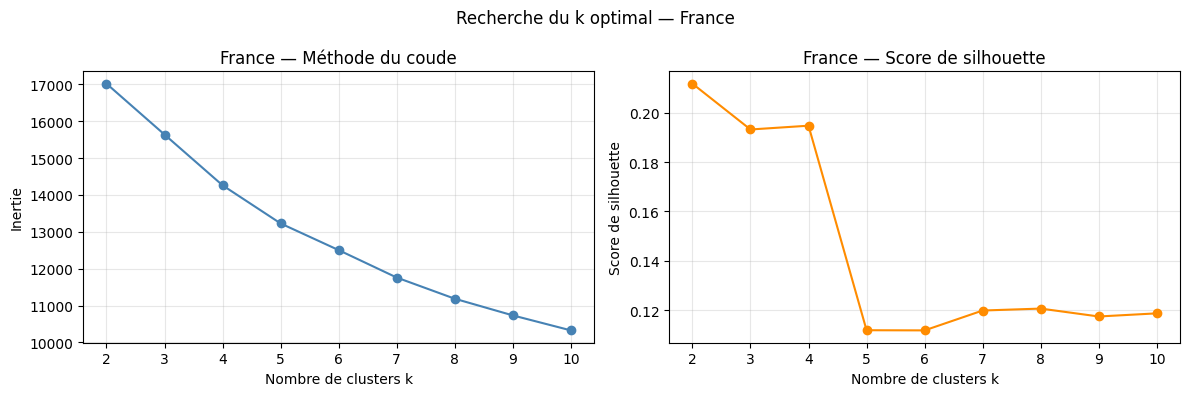

France : meilleur k selon silhouette = 2 (score = 0.212)


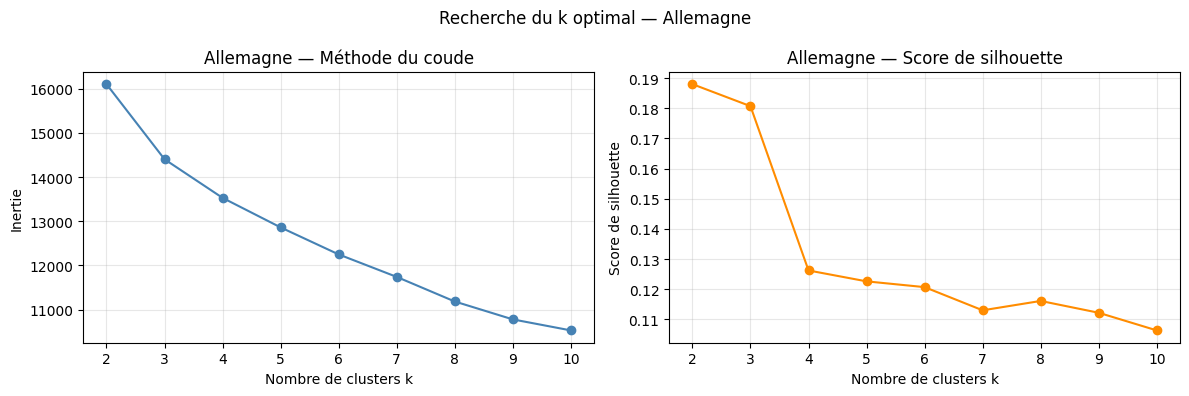

Allemagne : meilleur k selon silhouette = 2 (score = 0.188)


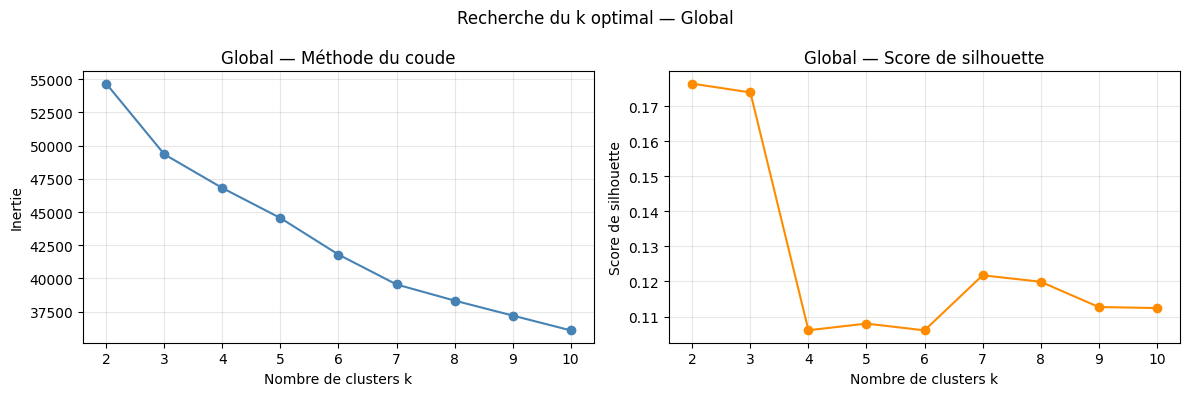

Global : meilleur k selon silhouette = 2 (score = 0.176)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_all_final = PCA(n_components=n95, random_state=42)
X_cluster_all = pca_all_final.fit_transform(x_train_pca)


def find_k_opt(X, label, k_range=range(2,11)):
    inerties    = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inerties.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_))

    # Graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Coude
    axes[0].plot(k_range, inerties, 'o-', color='steelblue')
    axes[0].set(xlabel='Nombre de clusters k', ylabel='Inertie',
                title=f'{label} — Méthode du coude')
    axes[0].grid(True, alpha=0.3)

    # Silhouette
    axes[1].plot(k_range, silhouettes, 'o-', color='darkorange')
    axes[1].set(xlabel='Nombre de clusters k', ylabel='Score de silhouette',
                title=f'{label} — Score de silhouette')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Recherche du k optimal — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()

    k_best = k_range[np.argmax(silhouettes)]
    print(f"{label} : meilleur k selon silhouette = {k_best} "
          f"(score = {max(silhouettes):.3f})")
    return k_best

k_best_fr = find_k_opt(X_cluster_fr, 'France')
k_best_de = find_k_opt(X_cluster_de, 'Allemagne')
k_best_all = find_k_opt(X_cluster_all, 'Global')


Les résultats confirment nos attentes : les données ne présentent pas de structures en clusters forte. 

**Score du coude** Les courbes (méthode du coude) décroissent sans rupture franche.

**Score de silhouette** Les scores sont tous inférieur à 0.25 ce qui est considéré comme faible.

In [67]:
km_fr  = KMeans(n_clusters=k_best_fr,  random_state=42, n_init=10)
km_de  = KMeans(n_clusters=k_best_de,  random_state=42, n_init=10)
km_all = KMeans(n_clusters=k_best_all, random_state=42, n_init=10)

labels_fr  = km_fr.fit_predict(X_cluster_fr)
labels_de  = km_de.fit_predict(X_cluster_de)
labels_all = km_all.fit_predict(X_cluster_all)

for label, labels in [('France', labels_fr), ('Allemagne', labels_de), ('Global', labels_all)]:
    repartition = dict(zip(*np.unique(labels, return_counts=True)))
    print(f"{label} — répartition : {repartition}")


France — répartition : {np.int32(0): np.int64(263), np.int32(1): np.int64(588)}
Allemagne — répartition : {np.int32(0): np.int64(383), np.int32(1): np.int64(260)}
Global — répartition : {np.int32(0): np.int64(593), np.int32(1): np.int64(901)}


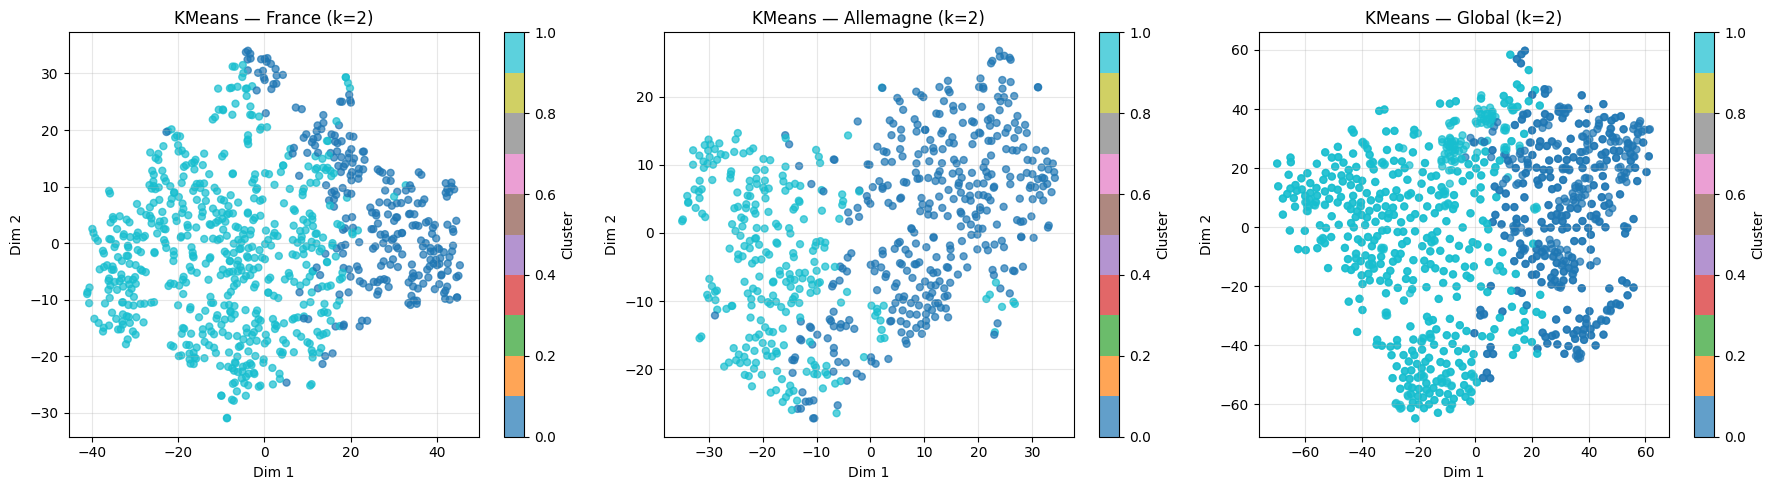

In [68]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X_c, labels, label in [
    (axes[0], X_fr,         labels_fr,  'France'),
    (axes[1], X_de,         labels_de,  'Allemagne'),
    (axes[2], x_train_pca,  labels_all, 'Global'),
]:
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000,
                learning_rate='auto', init='pca', random_state=42)
    Xt = tsne.fit_transform(X_c)

    sc = ax.scatter(Xt[:, 0], Xt[:, 1], c=labels,
                    cmap='tab10', alpha=0.7, s=25)
    plt.colorbar(sc, ax=ax, label='Cluster')
    ax.set(xlabel='Dim 1', ylabel='Dim 2',
           title=f'KMeans — {label} (k={labels.max()+1})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


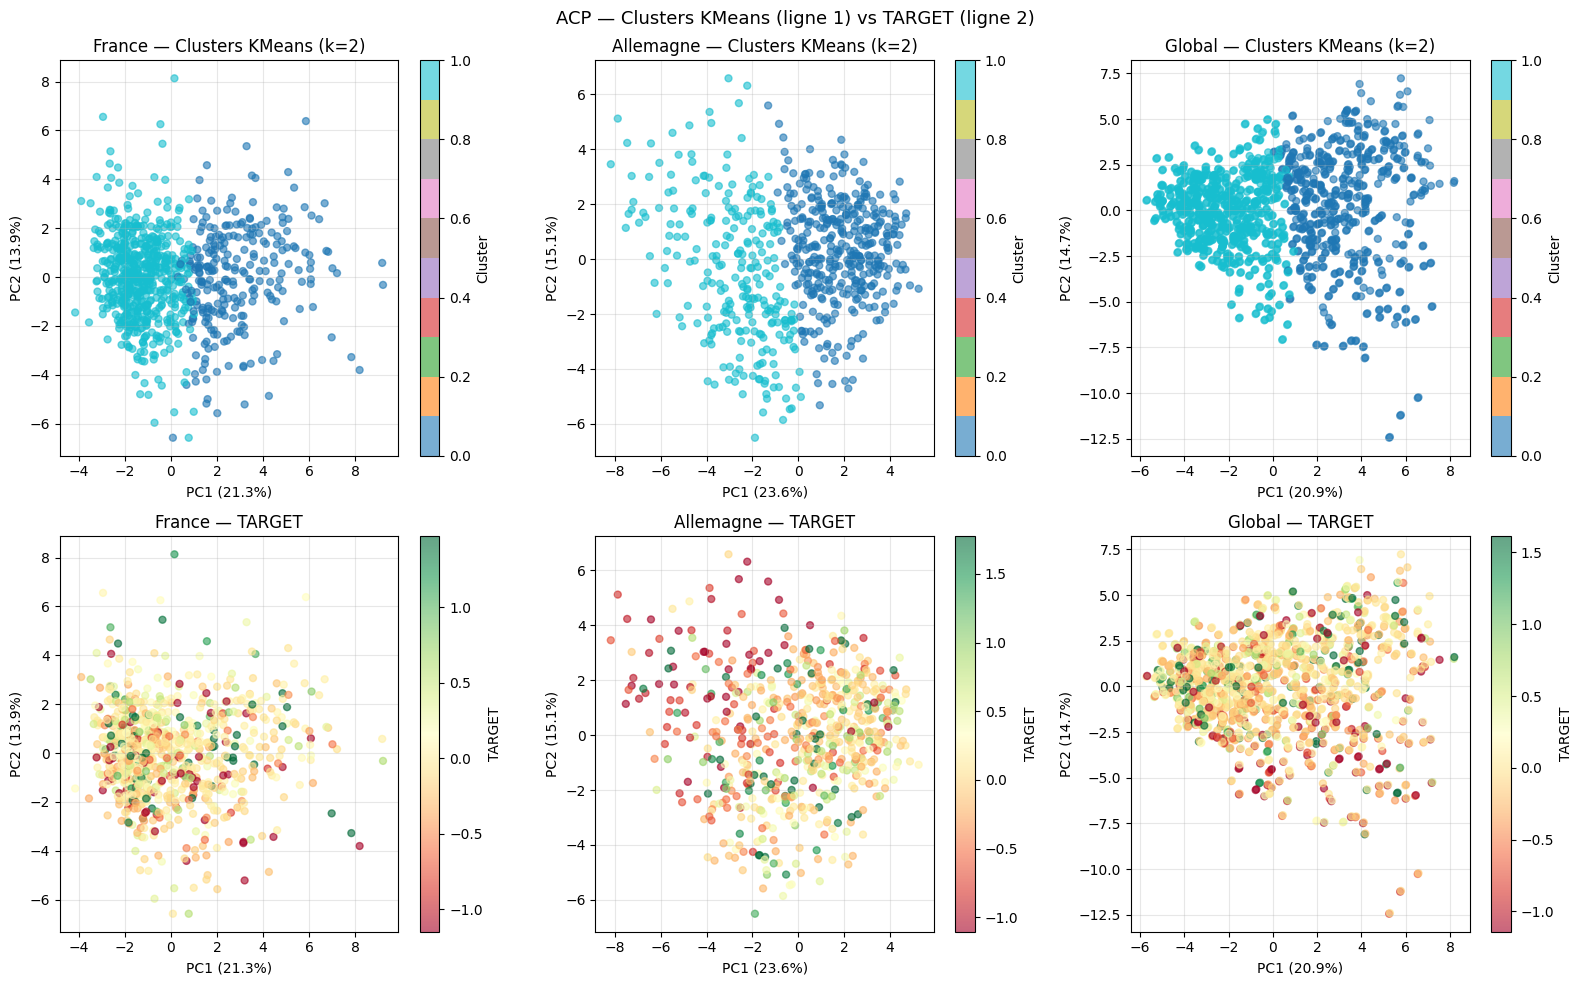

In [69]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (X_pca_2d, labels, label, ev) in enumerate([
    (X_pca_fr[:, :2], labels_fr,  'France',    pca_fr.explained_variance_ratio_),
    (X_pca_de[:, :2], labels_de,  'Allemagne', pca_de.explained_variance_ratio_),
    (X_proj[:, :2],   labels_all, 'Global',    pca_global.explained_variance_ratio_),
]):
    # Ligne 1 : clusters KMeans
    sc = axes[0, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                               c=labels, cmap='tab10',
                               alpha=0.6, s=25)
    plt.colorbar(sc, ax=axes[0, col], label='Cluster')
    axes[0, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — Clusters KMeans (k={labels.max()+1})')
    axes[0, col].grid(True, alpha=0.3)

    # Ligne 2 : TARGET
    y_vals = y_fr if label == 'France' else (y_de if label == 'Allemagne'
             else y_train_cv.loc[x_train_pca.index].values)
    sc2 = axes[1, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                                c=y_vals, cmap='RdYlGn',
                                alpha=0.6, s=25,
                                vmin=np.percentile(y_vals, 5),
                                vmax=np.percentile(y_vals, 95))
    plt.colorbar(sc2, ax=axes[1, col], label='TARGET')
    axes[1, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — TARGET')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('ACP — Clusters KMeans (ligne 1) vs TARGET (ligne 2)', fontsize=13)
plt.tight_layout()
plt.show()


In [70]:
for label, X_c, labels, feats, y_c in [
    ('France',    X_fr,        labels_fr,  FR_FEATS, y_fr),
    ('Allemagne', X_de,        labels_de,  DE_FEATS, y_de),
    ('Global',    x_train_pca, labels_all, selected_features_perm,
                  y_train_cv.loc[x_train_pca.index].values),
]:
    df_c = pd.DataFrame(X_c, columns=feats)
    df_c['cluster'] = labels
    df_c['TARGET']  = y_c

    print(f"\n{label.upper()}")
    print(df_c.groupby('cluster')[['TARGET'] + feats[:5]].mean().round(3).to_string())
    print()



FRANCE
         TARGET  FR_WIND_SOLAR_PROD  FR_WINDPOW  FR_NUCLEAR  FR_TEMP_x_RESIDUAL  FR_RAIN_x_HYDRO
cluster                                                                                         
0         0.074              -0.359       0.465       1.098              -0.384           -0.036
1         0.034               0.041      -0.252      -0.319               0.115            0.023


ALLEMAGNE
         TARGET  DE_NET_IMPORT  DE_NET_EXPORT  DE_TRADE_BALANCE  DE_HYDRO  DE_WIND_SOLAR_PROD
cluster                                                                                      
0         0.264          0.716         -0.716            -0.716     0.494               0.053
1        -0.023         -0.860          0.860             0.860    -0.571               0.059


GLOBAL
         TARGET  GAS_x_CARBON  DE_NET_IMPORT  DE_NET_EXPORT  DE_TRADE_BALANCE  DE_HYDRO
cluster                                                                                
0         0.047         0.071  

In [72]:
# Reconstruction des groupes DAY_ID par pays
day_id_map = x_train[['ID', 'DAY_ID']].set_index('ID')

grp_fr  = day_id_map.loc[x_train_pca.index[mask_fr], 'DAY_ID'].values
grp_de  = day_id_map.loc[x_train_pca.index[mask_de], 'DAY_ID'].values


In [73]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import make_scorer
from scipy.stats import spearmanr

spearman_scorer = make_scorer(
    lambda yt, yp: spearmanr(yt, yp).correlation,
    greater_is_better=True
)
ridge = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

y_all_vals = y_train_cv.loc[x_train_pca.index].values

for label, X_c, labels, y_c, grp in [
    ('France',    X_fr,        labels_fr,  y_fr,      grp_fr),
    ('Allemagne', X_de,        labels_de,  y_de,      grp_de),
    ('Global',    x_train_pca.values, labels_all, y_all_vals, groups),
]:
    gkf = GroupKFold(n_splits=5)

    # Sans cluster
    score_sans = cross_val_score(
        ridge, X_c, y_c,
        cv=list(gkf.split(X_c, y_c, groups=grp)),
        scoring=spearman_scorer, n_jobs=-1
    )

    # Avec cluster (one-hot)
    cluster_dummies = pd.get_dummies(labels, prefix='cluster').values
    X_avec = np.hstack([X_c, cluster_dummies])
    score_avec = cross_val_score(
        ridge, X_avec, y_c,
        cv=list(gkf.split(X_avec, y_c, groups=grp)),
        scoring=spearman_scorer, n_jobs=-1
    )

    gain = np.mean(score_avec) - np.mean(score_sans)
    print(f"{label}")
    print(f"  Sans cluster  : {np.mean(score_sans):.4f} ± {np.std(score_sans):.4f}")
    print(f"  Avec cluster  : {np.mean(score_avec):.4f} ± {np.std(score_avec):.4f}")
    print(f"  Gain KMeans   : {gain:+.4f}\n")


France
  Sans cluster  : 0.1400 ± 0.0911
  Avec cluster  : 0.1394 ± 0.0929
  Gain KMeans   : -0.0006

Allemagne
  Sans cluster  : 0.3469 ± 0.0344
  Avec cluster  : 0.3449 ± 0.0334
  Gain KMeans   : -0.0020

Global
  Sans cluster  : 0.2346 ± 0.0379
  Avec cluster  : 0.2339 ± 0.0382
  Gain KMeans   : -0.0007



### 6.3) Gaussian Mixture Model (GMM)

C'est un modele de clustering probabilitiste qui suppose que les données sont générées par un mélange de plusieurs distributions gaussiennes.

Le vrai intérêt du GMM ici n'est pas d'améliorer le score, mais de confirmer que les données ne présentent pas de structure en clusters exploitable pour la prédiction des prix, et de fournir une analyse de régimes de marché plus nuancée que KMeans.



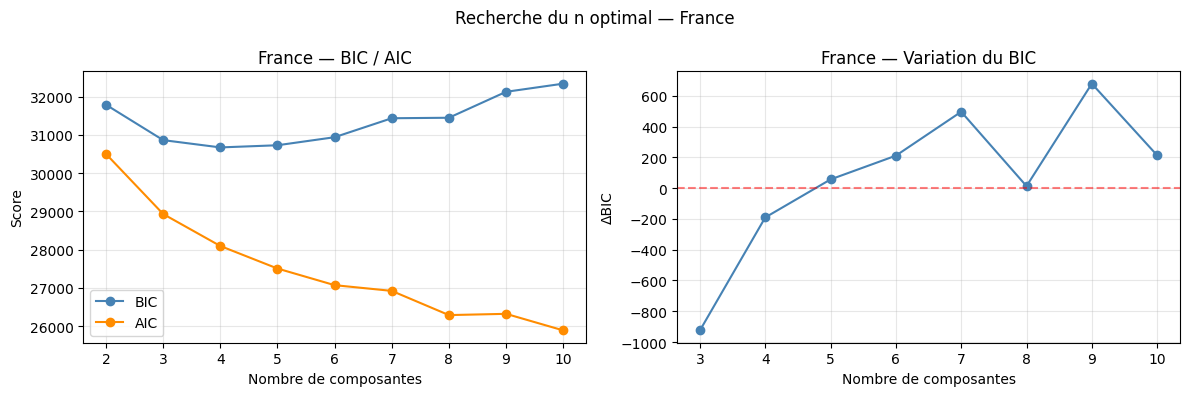

France : meilleur n selon BIC = 4 | selon AIC = 10


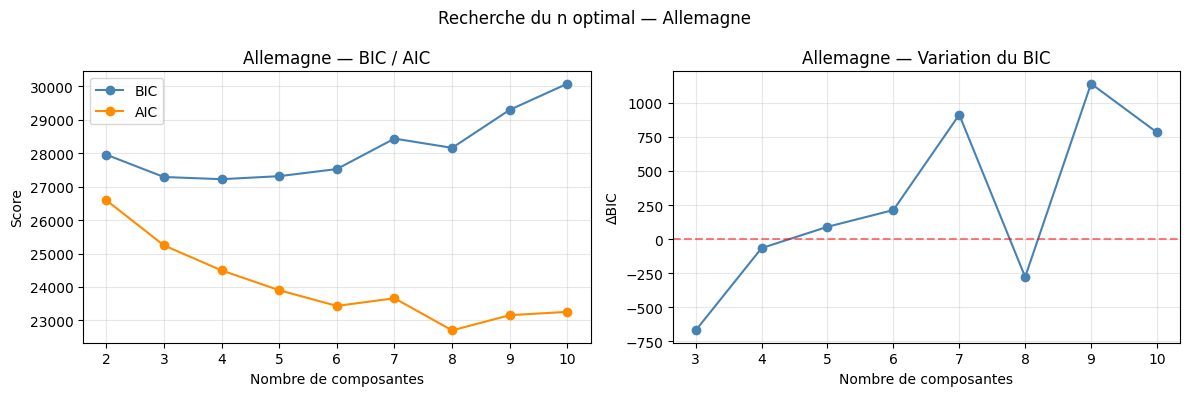

Allemagne : meilleur n selon BIC = 4 | selon AIC = 8


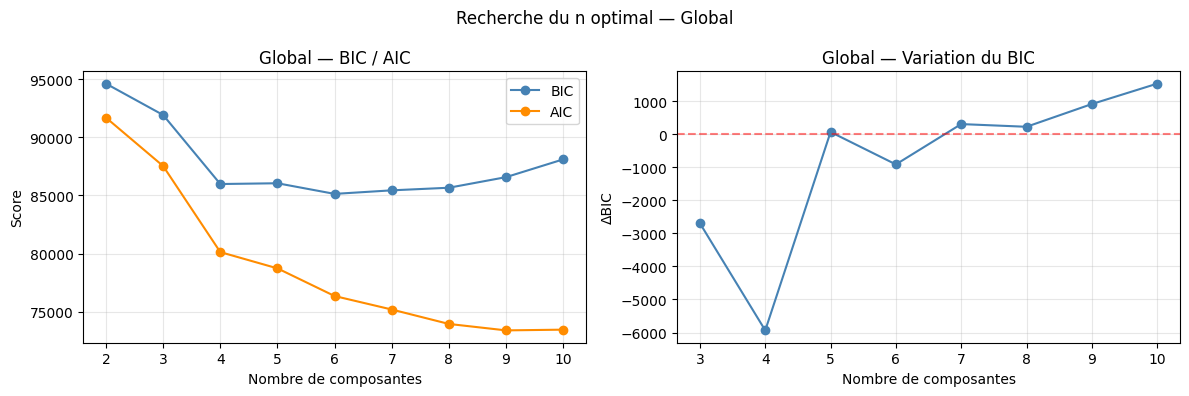

Global : meilleur n selon BIC = 6 | selon AIC = 9


In [74]:
from sklearn.mixture import GaussianMixture

def chercher_n_gmm(X, label, n_range=range(2, 11)):
    bics, aics = [], []

    for n in n_range:
        gmm = GaussianMixture(n_components=n, covariance_type='full',
                              random_state=42, n_init=5)
        gmm.fit(X)
        bics.append(gmm.bic(X))
        aics.append(gmm.aic(X))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(n_range, bics, 'o-', color='steelblue', label='BIC')
    axes[0].plot(n_range, aics, 'o-', color='darkorange', label='AIC')
    axes[0].set(xlabel='Nombre de composantes', ylabel='Score',
                title=f'{label} — BIC / AIC')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Différence pour voir le coude
    bic_diff = np.diff(bics)
    axes[1].plot(list(n_range)[1:], bic_diff, 'o-', color='steelblue')
    axes[1].axhline(0, color='red', ls='--', alpha=0.5)
    axes[1].set(xlabel='Nombre de composantes', ylabel='ΔBIC',
                title=f'{label} — Variation du BIC')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Recherche du n optimal — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()

    n_best_bic = n_range[np.argmin(bics)]
    n_best_aic = n_range[np.argmin(aics)]
    print(f"{label} : meilleur n selon BIC = {n_best_bic} | selon AIC = {n_best_aic}")
    return n_best_bic

n_gmm_fr  = chercher_n_gmm(X_cluster_fr,  'France')
n_gmm_de  = chercher_n_gmm(X_cluster_de,  'Allemagne')
n_gmm_all = chercher_n_gmm(X_cluster_all, 'Global')


In [75]:
cov_types = ['full', 'tied', 'diag', 'spherical']

print(f"{'Scope':<12} {'cov_type':<12} {'BIC':>10} {'AIC':>10}")
print('-' * 46)

best_gmms = {}
for label, X_c, n_c in [
    ('France',    X_cluster_fr,  n_gmm_fr),
    ('Allemagne', X_cluster_de,  n_gmm_de),
    ('Global',    X_cluster_all, n_gmm_all),
]:
    best_bic, best_gmm = np.inf, None
    for cov in cov_types:
        gmm = GaussianMixture(n_components=n_c, covariance_type=cov,
                              random_state=42, n_init=5)
        gmm.fit(X_c)
        bic, aic = gmm.bic(X_c), gmm.aic(X_c)
        marker = ' <-- meilleur' if bic < best_bic else ''
        print(f"{label:<12} {cov:<12} {bic:>10.1f} {aic:>10.1f}{marker}")
        if bic < best_bic:
            best_bic, best_gmm = bic, gmm
    best_gmms[label] = best_gmm
    print()

gmm_fr  = best_gmms['France']
gmm_de  = best_gmms['Allemagne']
gmm_all = best_gmms['Global']

labels_gmm_fr  = gmm_fr.predict(X_cluster_fr)
labels_gmm_de  = gmm_de.predict(X_cluster_de)
labels_gmm_all = gmm_all.predict(X_cluster_all)

for label, labels in [('France', labels_gmm_fr),
                       ('Allemagne', labels_gmm_de),
                       ('Global', labels_gmm_all)]:
    rep = dict(zip(*np.unique(labels, return_counts=True)))
    print(f"{label} — répartition : {rep}")


Scope        cov_type            BIC        AIC
----------------------------------------------
France       full            30671.4    28094.1 <-- meilleur
France       tied            36850.4    35981.8
France       diag            34856.7    34272.9
France       spherical       38205.1    37887.1

Allemagne    full            27225.9    24497.1 <-- meilleur
Allemagne    tied            32631.5    31724.8
Allemagne    diag            30267.3    29682.2
Allemagne    spherical       32999.7    32682.6

Global       full            85136.3    76349.5 <-- meilleur
Global       tied           102125.5   100054.9
Global       diag            95642.9    94214.7
Global       spherical      103731.5   102972.2

France — répartition : {np.int64(0): np.int64(210), np.int64(1): np.int64(25), np.int64(2): np.int64(429), np.int64(3): np.int64(187)}
Allemagne — répartition : {np.int64(0): np.int64(94), np.int64(1): np.int64(221), np.int64(2): np.int64(300), np.int64(3): np.int64(28)}
Global — répart

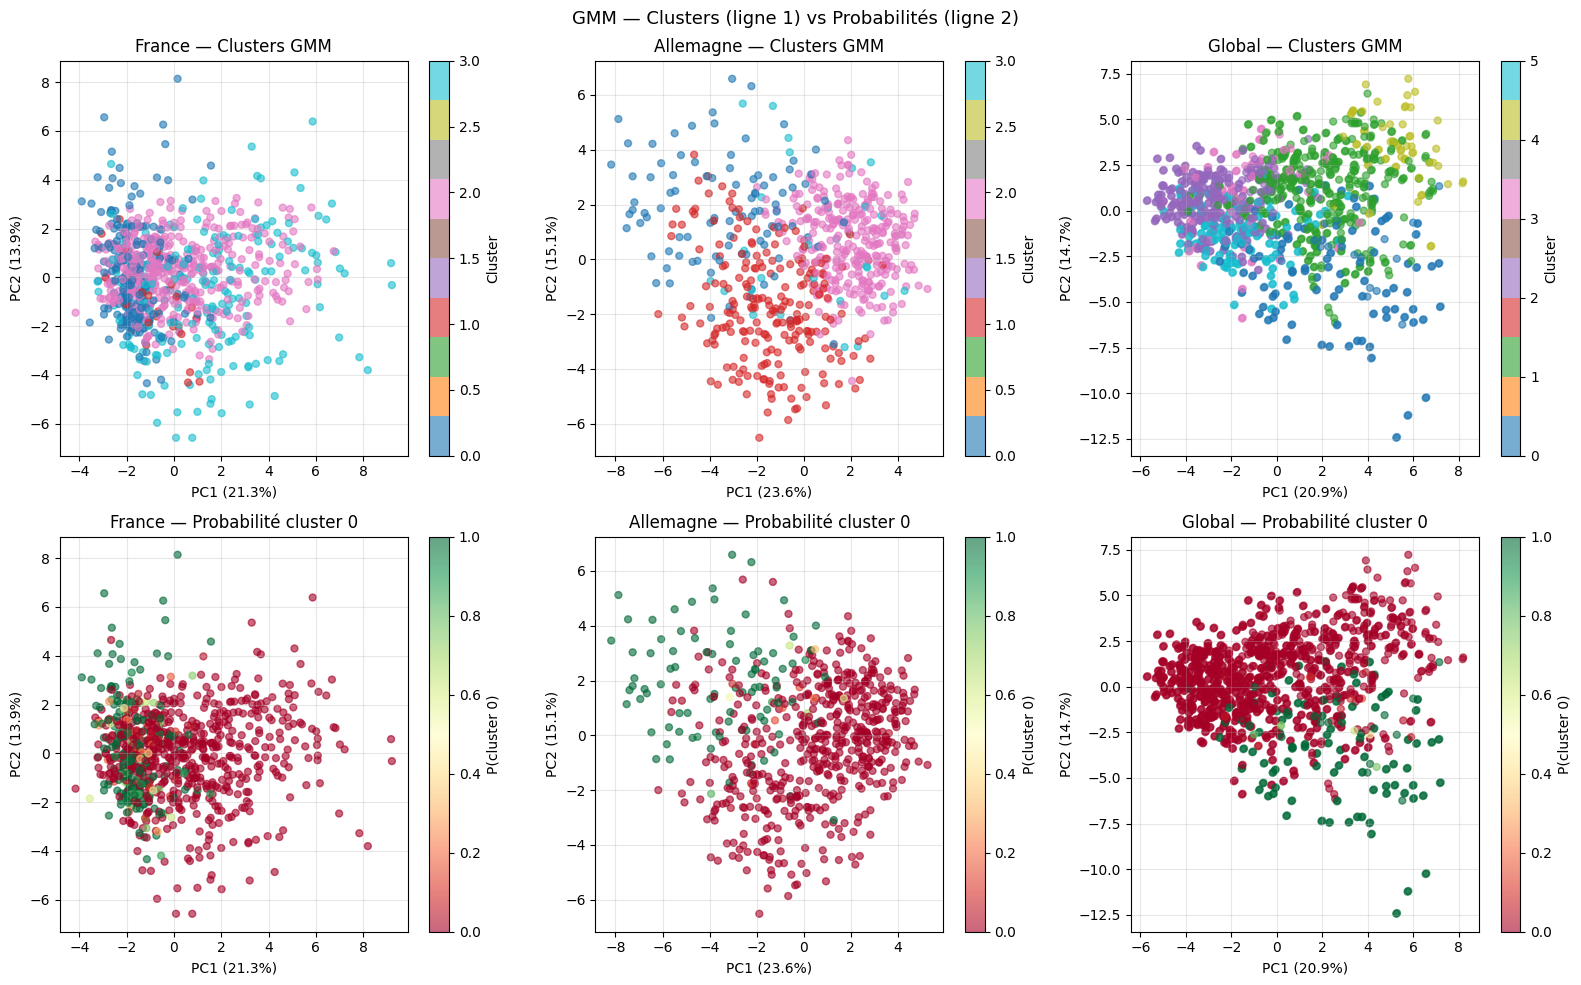

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, (X_pca_2d, X_c, gmm_c, labels, label, ev) in enumerate([
    (X_pca_fr[:, :2], X_cluster_fr,  gmm_fr,  labels_gmm_fr,  'France',    pca_fr.explained_variance_ratio_),
    (X_pca_de[:, :2], X_cluster_de,  gmm_de,  labels_gmm_de,  'Allemagne', pca_de.explained_variance_ratio_),
    (X_proj[:, :2],   X_cluster_all, gmm_all, labels_gmm_all, 'Global',    pca_global.explained_variance_ratio_),
]):
    # Ligne 1 : clusters GMM (hard assignment)
    sc = axes[0, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                               c=labels, cmap='tab10', alpha=0.6, s=25)
    plt.colorbar(sc, ax=axes[0, col], label='Cluster')
    axes[0, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — Clusters GMM')
    axes[0, col].grid(True, alpha=0.3)

    # Ligne 2 : probabilité d'appartenance au cluster 0 (soft assignment)
    proba = gmm_c.predict_proba(X_c)[:, 0]
    sc2 = axes[1, col].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                                c=proba, cmap='RdYlGn', alpha=0.6, s=25,
                                vmin=0, vmax=1)
    plt.colorbar(sc2, ax=axes[1, col], label='P(cluster 0)')
    axes[1, col].set(xlabel=f'PC1 ({ev[0]:.1%})', ylabel=f'PC2 ({ev[1]:.1%})',
                     title=f'{label} — Probabilité cluster 0')
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle('GMM — Clusters (ligne 1) vs Probabilités (ligne 2)', fontsize=13)
plt.tight_layout()
plt.show()


In [77]:
print(f"{'Scope':<12} {'KMeans':>10} {'GMM hard':>10} {'GMM soft':>12}")
print('-' * 48)

y_all_vals = y_train_cv.loc[x_train_pca.index].values

for label, X_c, labels_km, gmm_c, X_gmm, y_c, grp in [
    ('France',    X_fr.values,        labels_fr,  gmm_fr,
                  X_cluster_fr,  y_fr,      grp_fr),
    ('Allemagne', X_de.values,        labels_de,  gmm_de,
                  X_cluster_de,  y_de,      grp_de),
    ('Global',    x_train_pca.values, labels_all, gmm_all,
                  X_cluster_all, y_all_vals, groups),
]:
    gkf = GroupKFold(n_splits=5)
    cv  = list(gkf.split(X_c, y_c, groups=grp))
    r   = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

    # KMeans (one-hot)
    X_km   = np.hstack([X_c, pd.get_dummies(labels_km, prefix='c').values])
    s_km   = cross_val_score(r, X_km, y_c, cv=cv,
                              scoring=spearman_scorer, n_jobs=-1)

    # GMM hard (one-hot)
    labels_gmm = gmm_c.predict(X_gmm)
    X_gmm_h    = np.hstack([X_c, pd.get_dummies(labels_gmm, prefix='c').values])
    s_gmm_h    = cross_val_score(r, X_gmm_h, y_c, cv=cv,
                                  scoring=spearman_scorer, n_jobs=-1)

    # GMM soft (probabilités)
    probas  = gmm_c.predict_proba(X_gmm)
    X_gmm_s = np.hstack([X_c, probas])
    s_gmm_s = cross_val_score(r, X_gmm_s, y_c, cv=cv,
                               scoring=spearman_scorer, n_jobs=-1)

    print(f"{label:<12} {np.mean(s_km):>10.4f} "
          f"{np.mean(s_gmm_h):>10.4f} {np.mean(s_gmm_s):>12.4f}")


Scope            KMeans   GMM hard     GMM soft
------------------------------------------------
France           0.1394     0.1349       0.1340
Allemagne        0.3449     0.3492       0.3471
Global           0.2339     0.2329       0.2328


### 6.4) Hidden Markow Model (HMM)

Le HMM modélise une séquence d'observations en supposant qu'il existe des états cachés qui évoluent dans le temps selon une chaîne de Markov. Chaque état caché génère les observations visibles selon une distribution gaussienne


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Model is not converging.  Current: 9254.319069062127 is not greater than 39633.141352744104. Delta is -30378.822283681977
Model is not converging.  Current: 11624.15841888262 is not greater than 33384.871063939725. Delta is -21760.712645057105
Model is not converging.  Current: 11204.426210109703 is not greater than 36215.17084619126. Delta is -25010.744636081552
Model is not converging.  Current: 14088.36294904749 is not greater than 31743.95399536049. Delta is -17655.591046313
Model is not converging.  Current: 13558.51315237154 is not greater than 32587.72710191219. Delta is -19029.21394954065


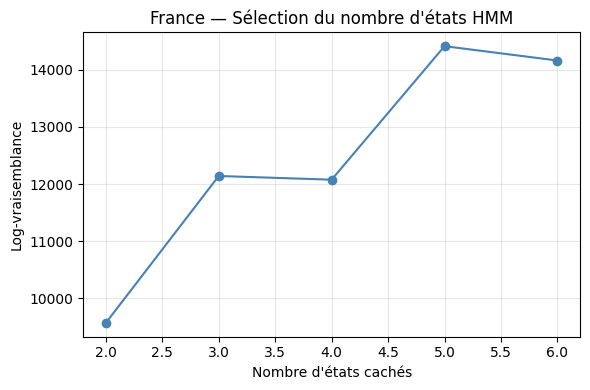

France : coude à n = 3


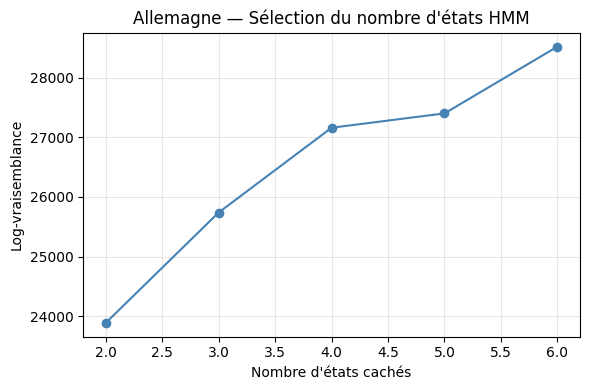

Allemagne : coude à n = 3


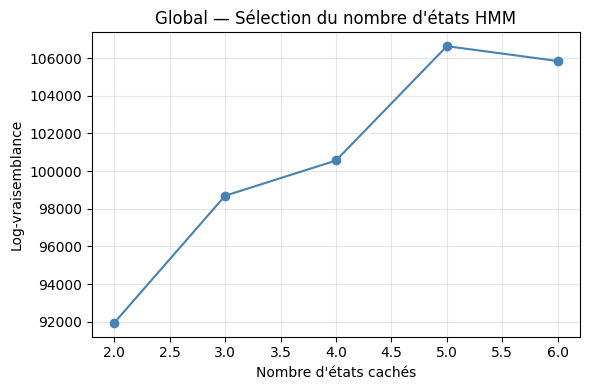

Model is not converging.  Current: 10085.460237550333 is not greater than 34663.34505014919. Delta is -24577.88481259886


Global : coude à n = 3
France — états : {np.int64(0): np.int64(48), np.int64(1): np.int64(691), np.int64(2): np.int64(112)}
Allemagne — états : {np.int64(0): np.int64(357), np.int64(1): np.int64(92), np.int64(2): np.int64(194)}
Global — états : {np.int64(0): np.int64(458), np.int64(1): np.int64(605), np.int64(2): np.int64(431)}

France — Matrice de transition :
        État 0  État 1  État 2
État 0   0.056   0.901   0.043
État 1   0.038   0.867   0.095
État 2   0.060   0.843   0.098

Allemagne — Matrice de transition :
        État 0  État 1  État 2
État 0   0.513   0.171   0.316
État 1   0.581   0.100   0.319
État 2   0.622   0.111   0.267

Global — Matrice de transition :
        État 0  État 1  État 2
État 0   0.615   0.232   0.153
État 1   0.174   0.680   0.147
État 2   0.168   0.200   0.632


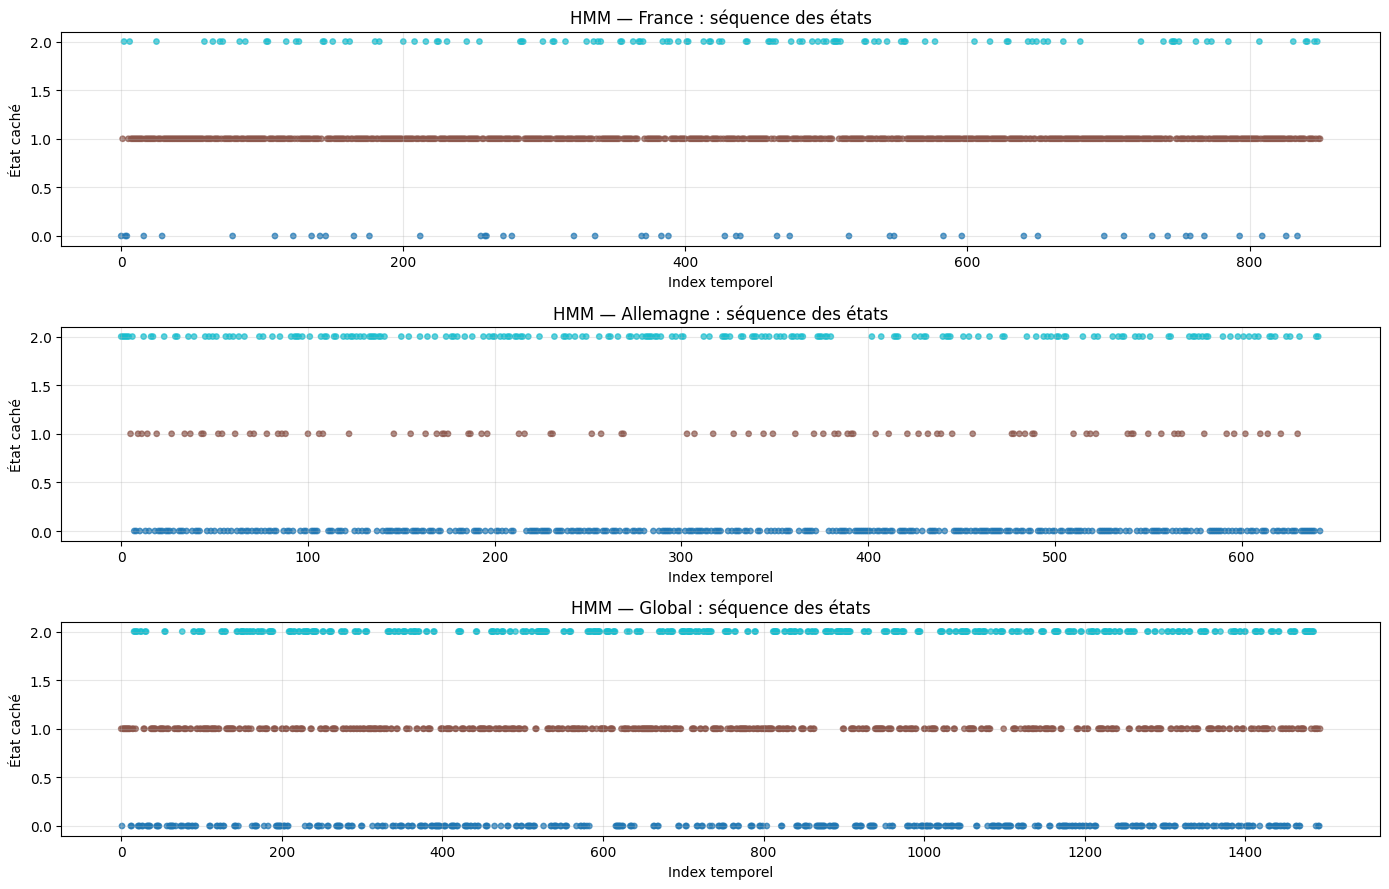


Scope          Sans HMM   Avec HMM     Gain
--------------------------------------------
France           0.1400     0.1426 + 0.0026
Allemagne        0.3469     0.3441 -0.0027
Global           0.2344     0.2330 -0.0014


In [78]:
try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'hmmlearn', '-q'])
    from hmmlearn.hmm import GaussianHMM

import warnings
warnings.filterwarnings('ignore')

# ── Reconstruction de l'ordre temporel ───────────────────────────────────────
day_id_map = x_train[['ID','DAY_ID']].set_index('ID')

def trier_par_day_id(X_df, mask):
    """Retourne X et les DAY_IDs triés chronologiquement."""
    ids     = x_train_pca.index[mask]
    day_ids = day_id_map.loc[ids, 'DAY_ID']
    order   = day_ids.argsort()
    return X_df.values[order], day_ids.values[order], order

X_fr_sorted, days_fr, order_fr = trier_par_day_id(X_fr, mask_fr)
X_de_sorted, days_de, order_de = trier_par_day_id(X_de, mask_de)
X_all_sorted = x_train_pca.values[x_train[['ID','DAY_ID']].set_index('ID').loc[
    x_train_pca.index,'DAY_ID'].argsort()]

y_fr_sorted  = y_fr[order_fr]
y_de_sorted  = y_de[order_de]


# ── Recherche du nombre d'états optimal (log-vraisemblance) ──────────────────
def chercher_n_hmm(X, label, n_range=range(2, 7)):
    scores = []
    for n in n_range:
        hmm = GaussianHMM(n_components=n, covariance_type='full',
                          n_iter=100, random_state=42)
        hmm.fit(X)
        scores.append(hmm.score(X))

    plt.figure(figsize=(6, 4))
    plt.plot(n_range, scores, 'o-', color='steelblue')
    plt.xlabel('Nombre d\'états cachés')
    plt.ylabel('Log-vraisemblance')
    plt.title(f'{label} — Sélection du nombre d\'états HMM')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    n_best = n_range[np.argmax(np.diff(scores)) + 1]
    print(f"{label} : coude à n = {n_best}")
    return n_best

n_hmm_fr  = chercher_n_hmm(X_fr_sorted,  'France')
n_hmm_de  = chercher_n_hmm(X_de_sorted,  'Allemagne')
n_hmm_all = chercher_n_hmm(X_all_sorted, 'Global')


# ── Entraînement final ────────────────────────────────────────────────────────
hmm_fr  = GaussianHMM(n_components=n_hmm_fr,  covariance_type='full',
                      n_iter=200, random_state=42)
hmm_de  = GaussianHMM(n_components=n_hmm_de,  covariance_type='full',
                      n_iter=200, random_state=42)
hmm_all = GaussianHMM(n_components=n_hmm_all, covariance_type='full',
                      n_iter=200, random_state=42)

hmm_fr.fit(X_fr_sorted)
hmm_de.fit(X_de_sorted)
hmm_all.fit(X_all_sorted)

states_fr  = hmm_fr.predict(X_fr_sorted)
states_de  = hmm_de.predict(X_de_sorted)
states_all = hmm_all.predict(X_all_sorted)

for label, states in [('France', states_fr),
                       ('Allemagne', states_de),
                       ('Global', states_all)]:
    rep = dict(zip(*np.unique(states, return_counts=True)))
    print(f"{label} — états : {rep}")


# ── Probabilités de transition ────────────────────────────────────────────────
for label, hmm_c, n_c in [('France',    hmm_fr,  n_hmm_fr),
                            ('Allemagne', hmm_de,  n_hmm_de),
                            ('Global',    hmm_all, n_hmm_all)]:
    print(f"\n{label} — Matrice de transition :")
    trans_df = pd.DataFrame(hmm_c.transmat_.round(3),
                            index=[f'État {i}' for i in range(n_c)],
                            columns=[f'État {i}' for i in range(n_c)])
    print(trans_df.to_string())


# ── Visualisation : états dans le temps ──────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

for ax, days, states, label in [
    (axes[0], days_fr, states_fr,  'France'),
    (axes[1], days_de, states_de,  'Allemagne'),
    (axes[2], x_train[['ID','DAY_ID']].set_index('ID').loc[
               x_train_pca.index,'DAY_ID'].sort_values().values,
               states_all, 'Global'),
]:
    ax.scatter(range(len(states)), states, c=states,
               cmap='tab10', s=15, alpha=0.7)
    ax.set(xlabel='Index temporel', ylabel='État caché',
           title=f'HMM — {label} : séquence des états')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ── Évaluation Spearman : Ridge seul vs Ridge + états HMM ────────────────────
print(f"\n{'Scope':<12} {'Sans HMM':>10} {'Avec HMM':>10} {'Gain':>8}")
print('-' * 44)

for label, X_c, states, y_c, grp in [
    ('France',    X_fr_sorted,  states_fr,  y_fr_sorted,
                  days_fr),
    ('Allemagne', X_de_sorted,  states_de,  y_de_sorted,
                  days_de),
    ('Global',    X_all_sorted, states_all,
                  y_train_cv.loc[x_train_pca.index].values[
                      day_id_map.loc[x_train_pca.index,'DAY_ID'].argsort()],
                  day_id_map.loc[x_train_pca.index,'DAY_ID'].sort_values().values),
]:
    gkf = GroupKFold(n_splits=5)
    cv  = list(gkf.split(X_c, y_c, groups=grp))
    r   = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

    s_sans = cross_val_score(r, X_c, y_c, cv=cv,
                              scoring=spearman_scorer, n_jobs=-1)

    state_oh = pd.get_dummies(states, prefix='state').values
    X_avec   = np.hstack([X_c, state_oh])
    s_avec   = cross_val_score(r, X_avec, y_c, cv=cv,
                                scoring=spearman_scorer, n_jobs=-1)

    gain  = np.mean(s_avec) - np.mean(s_sans)
    signe = '+' if gain >= 0 else ''
    print(f"{label:<12} {np.mean(s_sans):>10.4f} "
          f"{np.mean(s_avec):>10.4f} {signe}{gain:>7.4f}")


## 7) Modèle supervisé

### 7.1) Classification

Dans cette partie, nous allons tester plusieurs modèle de classification différents et comparer notre accuracy pour nos 3 methodes de données afin de trouver le modèle le plus performants.

##### **Selection des modèles**

Il faut discretiser y_train. On peut utiliser une conversion en entier relatif (avec le signe). Nous avons choisi de prendre la valeur entière la plus proche que nous avons plafonnée entre -15 et 20.

In [ ]:
result_supervised = []
for i,method in enumerate(methods):
    # Split
    nom,X_train_method,y_train_method,X_test_method=method
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = sk.model_selection.train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
    #y_train_method_train = y_train_method_train.astype(int)['cible']
    y_train_method_train=np.clip(y_train_method_train.astype(int), -15, 20)

    # Random Forest
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train_method_train, y_train_method_train)
    y_pred_rf = rf_model.predict(X_train_method_test)
    weighted_acc_rf = weighted_accuracy(y_train_method_test['cible'], y_pred_rf)
    result_supervised.append((f"Methode_{nom}","RF",weighted_acc_rf,rf_model))
    
    # SVM
    svm_model = SVC(random_state=42)
    svm_model.fit(X_train_method_train, y_train_method_train)
    y_pred_svm = svm_model.predict(X_train_method_test)
    weighted_acc_svm = weighted_accuracy(y_train_method_test['cible'], y_pred_svm)
    result_supervised.append((f"Methode_{nom}","SVM",weighted_acc_svm,svm_model))

    # Regression logistique
    rl_model = LogisticRegression(multi_class='multinomial')
    rl_model.fit(X_train_method_train, y_train_method_train)
    y_pred_rl = rl_model.predict(X_train_method_test)
    weighted_acc_rl = weighted_accuracy(y_train_method_test['cible'], y_pred_rl)
    result_supervised.append((f"Methode_{nom}","Logistic",weighted_acc_rl,rl_model))

    # KNN
    knn_model = KNeighborsClassifier(n_neighbors=5)
    knn_model.fit(X_train_method_train, y_train_method_train)
    y_pred_knn = knn_model.predict(X_train_method_test)
    weighted_acc_knn = weighted_accuracy(y_train_method_test['cible'], y_pred_knn)
    result_supervised.append((f"Methode_{nom}","KNN",weighted_acc_knn,knn_model))

result_supervised=pd.DataFrame(result_supervised,columns=[f"Methode","Type","W_Accuracy","Modele"])
result_supervised.sort_values('W_Accuracy',inplace=True)

In [ ]:
result_supervised

In [ ]:
result_supervised

Avec nos resultats, le modèle de Random Forest avec la methode de données 3 parait la plus performante. Nous allons donc retenir ces choix et faire une optimisation des hyperparamètres afin de trouver le modèle le plus performant.

##### **Optimisation des hyperparamètre**

In [ ]:
nom,X_train_method,y_train_method,X_test_method = methods[1]
nom = 'Cluster'

In [ ]:
X_train_train, X_train_test, y_train_train, y_train_test = sk.model_selection.train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
y_train_train = np.clip(y_train_method_train.astype(int), -15, 20)
 #y_train_train.astype(int)['cible']

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],  # Nombre d'arbres dans la forêt
    'max_features': ['sqrt', 'log2'],  # Nombre de caractéristiques à considérer à chaque division
    'max_depth': [None, 10, 15],  # Profondeur maximale de l'arbre
    'min_samples_split': [2, 5],  # Nombre minimum de données nécessaires pour diviser un nœud
    'min_samples_leaf': [1, 2, 4]  # Nombre minimum de données requises à chaque feuille
}

rf = RandomForestClassifier(random_state=42)
grid_search = sk.model_selection.GridSearchCV(estimator=rf, param_grid=param_grid,scoring=custom_score, cv=3, n_jobs=None, verbose=0)
grid_search.fit(X_train_train, y_train_train)
print("Meilleurs paramètres trouvés : ", grid_search.best_params_)

In [ ]:
model_rf = grid_search.best_estimator_
pred = model_rf.predict(X_train_test)
weighted_acc = weighted_accuracy(y_train_test['cible'], pred)
comparaison.append([f"Methode_{nom}","RandomForestClassifier",weighted_acc])
weighted_acc

In [ ]:
#model_rf.get_params()

##### **Prediction sur nos données X_test**

In [ ]:
y_test_final = model_rf.predict(X_test_method)
y_test_final = pd.DataFrame(y_test_final,index=X_test_method.index,columns=["cible"])
y_test_final.to_csv("y_rf.csv")

Sur la plateforme, nous obtenons 0,4781.

### 7.2) Regression

##### **Selection des modèles**

In [ ]:
result_supervised = []
for i,method in enumerate(methods):
    # Split
    nom,X_train_method,y_train_method,X_test_method=method
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = sk.model_selection.train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
    
    # LinearRegression
    lin_model = LinearRegression()
    lin_model.fit(X_train_method_train, y_train_method_train)
    y_pred_lin = lin_model.predict(X_train_method_test)
    weighted_acc_lin = weighted_accuracy(y_train_method_test, y_pred_lin)['cible']
    result_supervised.append((f"Methode_{nom}","Linear",weighted_acc_lin,lin_model))
    
    # Ridge
    ridge_model = Ridge(alpha=0.1,random_state=42)
    ridge_model.fit(X_train_method_train, y_train_method_train)
    y_pred_ridge = ridge_model.predict(X_train_method_test)
    weighted_acc_ridge = weighted_accuracy(y_train_method_test, y_pred_ridge)['cible']
    result_supervised.append((f"Methode_{nom}","ridge",weighted_acc_ridge,ridge_model))

    # SVR
    svr_model = SVR()
    svr_model.fit(X_train_method_train, y_train_method_train)
    y_pred_svr = svr_model.predict(X_train_method_test)
    weighted_acc_svr = weighted_accuracy(y_train_method_test['cible'], y_pred_svr)
    result_supervised.append((f"Methode_{nom}","SVR",weighted_acc_svr,svr_model))

    # RandomForestRegressor
    rf_model = RandomForestRegressor(n_estimators=100)
    rf_model.fit(X_train_method_train, y_train_method_train)
    y_pred_rf = rf_model.predict(X_train_method_test)
    weighted_acc_rf = weighted_accuracy(y_train_method_test['cible'], y_pred_rf)
    result_supervised.append((f"Methode_{nom}","RF",weighted_acc_rf,rf_model))

result_supervised=pd.DataFrame(result_supervised,columns=[f"Methode","Type","W_Accuracy","Modele"])
result_supervised.sort_values('W_Accuracy',inplace=True)

In [ ]:
result_supervised

Le random Forest semble être le modèle le plus performant. Nous allons optimiser ses paramètres afin d'obtenir le meilleur modèle possible.

##### **Optimisation des hyperparamètre**

In [ ]:
nom="Standard"
X_train_3_train, X_train_3_test, y_train_3_train, y_train_3_test = sk.model_selection.train_test_split(X_train_3, y_train_3, test_size=0.2, random_state=42)

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150],  # Nombre d'arbres dans la forêt
    'max_features': ['sqrt', 'log2'],  # Nombre de caractéristiques à considérer à chaque division
    'max_depth': [None, 10, 15],  # Profondeur maximale de l'arbre
    'min_samples_split': [2, 5],  # Nombre minimum de données nécessaires pour diviser un nœud
    'min_samples_leaf': [1, 2, 4]  # Nombre minimum de données requises à chaque feuille
}

rf = RandomForestRegressor(random_state=42)
grid_search = sk.model_selection.GridSearchCV(estimator=rf, param_grid=param_grid,scoring=custom_score, cv=3, n_jobs=None, verbose=0)
grid_search.fit(X_train_3_train, y_train_3_train.astype(int))
print("Meilleurs paramètres trouvés : ", grid_search.best_params_)

In [ ]:
model_rf = grid_search.best_estimator_
pred = model_rf.predict(X_train_3_test)
weighted_acc = weighted_accuracy(y_train_3_test['cible'], pred)
comparaison.append([f"Methode_{nom}","RandomForestRegressor",weighted_acc])
weighted_acc

##### **Prediction sur nos données X_test**

In [ ]:
y_test_final = model_rf.predict(X_test_3)
y_test_final = pd.DataFrame(y_test_final,index=X_test_3.index,columns=["cible"])
y_test_final.to_csv("y_rf_reg.csv")

### 7.3) Modèle d'ensemble

Nous allons également utiliser un modèle "VotingClassifier" qui nous permet de combiner plusieurs modèles d'apprentissage pour obtenir une prédiction. 

**Ajustement des données**

In [ ]:
Nnom = "Standard"
X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_3, y_train_3, test_size=0.2, random_state=42)
y_train_method_train = np.clip(y_train_method_train.astype(int), 0, 5)


**Creation du modèle**

In [ ]:
# Définir les modèles individuels
model1 = LogisticRegression()
model2 = RandomForestClassifier()
model3 = KNeighborsClassifier()

# Créer le VotingClassifier
voting_hard = VotingClassifier(estimators=[('lr', model1), ('rf', model2), ('knn', model3)], voting='hard')
voting_soft = VotingClassifier(estimators=[('lr', model1), ('rf', model2), ('knn', model3)], voting='soft')

**Optimisation des hyperparamètre**

In [ ]:
# Définir l'espace des hyperparamètres à explorer
param_grid = {
    'lr__C': [0.1, 1, 10],             
    'rf__n_estimators': [50, 100, 200], 
    'rf__max_depth': [None, 10, 20],    
    'knn__n_neighbors': [3, 5, 7],      
    'knn__weights': ['uniform', 'distance'] 
}

# Recherche d'hyperparamètres avec validation croisée
grid_search_hard = GridSearchCV(estimator=voting_hard, param_grid=param_grid, scoring=custom_score, cv=5)
grid_search_hard.fit(X_train_method_train, y_train_method_train)

grid_search_soft = GridSearchCV(estimator=voting_hard, param_grid=param_grid,scoring=custom_score, cv=5)
grid_search_soft.fit(X_train_method_train, y_train_method_train)

# Afficher les meilleurs hyperparamètres et la meilleure précision
print("Meilleurs hyperparamètres hard:", grid_search_hard.best_params_)
print("Meilleurs hyperparamètres hard:", grid_search_soft.best_params_)

In [ ]:
model_soft = grid_search_soft.best_estimator_
model_hard = grid_search_hard.best_estimator_

In [ ]:
# Prediction avec le VotingClassifier
y_pred_hard = model_soft.predict(X_train_method_test)
y_pred_soft = model_hard.predict(X_train_method_test)

# Calculer Metrique
accuracy_soft = weighted_accuracy(y_train_method_test['cible'], y_pred_soft)
accuracy_hard = weighted_accuracy(y_train_method_test['cible'], y_pred_hard)
comparaison.append([f"Methode_{nom}","VotingClassifierSoft",accuracy_soft])
comparaison.append([f"Methode_{nom}","VotingClassifierHard",accuracy_hard])

print("Weighted Accuracy du VotingClassifier Soft :", accuracy_soft)
print("Weighted Accuracy du VotingClassifier Hard:", accuracy_hard)

##### **Predictions**

In [ ]:
y_pred_hard = model_soft.predict(X_test_3)
y_pred_soft = model_hard.predict(X_test_3)

In [ ]:
y_pred_hard = pd.DataFrame(y_pred_hard,index=X_test_3.index,columns=['cible'])
y_pred_soft = pd.DataFrame(y_pred_soft,index=X_test_3.index,columns=['cible'])
y_pred_hard.to_csv("y_test_hard.csv")
y_pred_soft.to_csv("y_test_soft.csv")

## 8) Intérprétation des modèles 

**Interpretation de l'importances des variables explicatives**

In [ ]:
# Get feature importances from the model
feature_importances = pd.DataFrame({
    'Feature': X_train_3.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
feature_importances

Nous constatons que dans ce modèle de regression Random Forest, la variable la plus importante est *load_forecast* et *nuclear_power_available*. 

**Interpretation détaillée**

In [ ]:
explainer = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_train_3)

In [ ]:
class_index = 23
shap.summary_plot(shap_values[:, :], X_train_3, plot_type="bar")


In [ ]:
style = """
<style>
    .lime, .lime * {
        background-color: #BBD;
        color: black;
    }
</style>
"""
HTML(style)


In [ ]:
# Initialiser l'expliqueur LIME pour les données tabulaires
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_3.values,
    feature_names=X_train_3.columns,
    class_names=['cible'],
    mode='regression'
)

# Choisissez une instance spécifique que vous souhaitez expliquer
i = 23  # index de l'instance dans X_train_imputed
exp = explainer.explain_instance(
    data_row=X_train_3.iloc[i].values, 
    predict_fn=model_rf.predict
)

# Afficher l'explication
exp.show_in_notebook(show_table=True, show_all=False)


## 9) Modèle de Deep Learning

### 9.1) Réseau de Neurone standard

##### **Definition de notre metrique**

Nous commençons par définir notre métrique en tensorflow pour pouvoir ensuite l'utiliser dans nos réseaux de neurones.

In [ ]:
# Définition de la métrique 
class WeightedAccuracy(Metric):
    def __init__(self, name="weighted_accuracy", **kwargs):
        super(WeightedAccuracy, self).__init__(name=name, **kwargs)
        self.total_weighted_accuracy = self.add_weight(name="total_weighted_accuracy", initializer="zeros")
        self.total_weight = self.add_weight(name="total_weight", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > 0.5, tf.float32)
        correct_predictions = tf.cast(tf.equal(tf.sign(y_true), tf.sign(y_pred)), tf.float32)
        weights = tf.abs(y_true)
        weighted_correct_predictions = correct_predictions * weights
        self.total_weighted_accuracy.assign_add(tf.reduce_sum(weighted_correct_predictions))
        self.total_weight.assign_add(tf.reduce_sum(weights))

    def result(self):
        return self.total_weighted_accuracy / self.total_weight

    def reset_states(self):
        self.total_weighted_accuracy.assign(0)
        self.total_weight.assign(0)

##### **Construction du modèle et entrainement du modèle**

Nous construisons ensuite notre modèle. Nous sommes partis sur un réseau en 4 couches simples qui essaye de maximiser notre métrique "WeightedAccuracy"

Nous entrainons un modèle par méthode de données en essayant de maximiser notre métrique. Nous utilisons également un checkpoint qui va nous permettre de récupérer le meilleure modèle même si ne n'est pas le dernier produit.

In [ ]:
# Entraînement du modèle
result_reseau = []
for i,method in enumerate(methods):
    print("Methode ",i+1)
    nom,X_train_method,y_train_method,X_test_method = method
    X_train_method_train, X_train_method_test, y_train_method_train, y_train_method_test = train_test_split(X_train_method, y_train_method, test_size=0.2, random_state=42)
    
    model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_method_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=[WeightedAccuracy()])
    checkpoint = ModelCheckpoint(
        'model_deeplearning.h5',          
        monitor='weighted_accuracy', 
        verbose=0,              
        save_best_only=True,   
        mode='max',               
        save_weights_only=False   
    )
    history = model.fit(X_train_method_train, y_train_method_train, epochs=40, batch_size=32, validation_split=0.2,verbose=0, callbacks=[checkpoint])
    # Recuperation du meilleur modèle
    model_reseau = load_model('model_deeplearning.h5', custom_objects={'WeightedAccuracy': WeightedAccuracy})
    y_res= model_reseau.predict(X_train_method_test,verbose=0)
    w_acc= weighted_accuracy(y_train_method_test,y_res)['cible']
    result_reseau.append([f"Methode_{nom}","Reseau",w_acc,model_reseau])
    comparaison.append([f"Methode_{nom}","Reseau",w_acc])

result_reseau=pd.DataFrame(result_reseau,columns=[f"Methode_{i+1}","Type","W_Accuracy","Modele"])

In [ ]:
result_reseau

Nous constatons que les résultats ne sont pas très encourageant. Le modèle reste quand même plus performant sur nos données traité par la méthode 3.

##### **Prédiction sur nos données X_test**

In [ ]:
model_reseau = result_reseau.Modele.iloc[0]

In [ ]:
y_reseau = model_reseau.predict(X_test_3)
y_reseau = pd.DataFrame(y_reseau,index=X_test_3.index,columns=['cible'])
y_reseau.to_csv('y_test_reseau.csv')

### 9.2) Modèle LSTM

##### **Création du modèle**

In [ ]:
# Define the LSTM model
model_lstm = Sequential([
    LSTM(50, input_shape=(1, 11), return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error',metrics=[WeightedAccuracy()])

##### **Entrainement du modèle**

Nous utilisons un "EarlyStopping" qui nous permet d'arrêter l'entrainement quand la métrique n'augmente plus pour éviter l'overfitting.

In [ ]:
# Formatage des données
split_point = int(0.8 * len(X_train_3))
X_train_res = X_train_3[:split_point]
y_train_res = y_train_3[:split_point]
X_test_res = X_train_3[split_point:]
y_test_res = y_train_3[split_point:]

# Reshaping pour LSTM si nécessaire
X_train_res = X_train_res.values.reshape((X_train_res.shape[0], 1, X_train_res.shape[1]))
X_test_res = X_test_res.values.reshape((X_test_res.shape[0], 1, X_test_res.shape[1]))

# Entrainement du modèle
early_stopping = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
history = model_lstm.fit(X_train_res, y_train_res, epochs=100, validation_split=0.2, verbose=1, batch_size=32,callbacks=[early_stopping])

In [ ]:
y_res_LSTM= model_lstm.predict(X_test_res,verbose=0)
w_acc_LSTM = weighted_accuracy(y_test_res,y_res_LSTM)
comparaison.append([f"Methode_Standard","LSTM",w_acc_LSTM])

print("WeightedAccuracy pour le LSTM : ",w_acc_LSTM['cible']) 

##### **Prediction sur X_test**

In [ ]:
X_test_3_reshaped = X_test_3.values.reshape((X_test_3.shape[0], 1, X_test_3.shape[1]))
y_test_LSTM = model_lstm.predict(X_test_3_reshaped)
y_test_LSTM = pd.DataFrame(y_test_LSTM,index=X_test_3.index,columns=['cible'])
y_test_LSTM = y_test_LSTM.to_csv('y_test_LSTM.csv')

## 10) Comparaison des résultats

In [ ]:
comparaison_finale = pd.DataFrame(comparaison,columns=['Methode',"Modele","Weighted_Accuracy"])
print(tabulate(comparaison_finale, headers = "keys", tablefmt = "fancy_grid"))

Interprétation

## 11) XAI sur 1 ou 2 modèles (très important, à minima ce que l'on a vu en cours mais il existe de plus récentes approche comme XPER, dans ce projet ce n'était pas assez détaillé)